In [1]:
import sys
sys.path.append('../python-pipeline/')
from modules import *
from wavelets import *

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, integrate, stats, interpolate
import seaborn as sn
from tqdm import tqdm

plt.rcParams['figure.dpi'] = 300

In [3]:
# # Load data
# dataFrameLeft = pd.read_csv(f'/Users/igavier/Downloads/capture24/P002.csv')
# dataFrameLeft.rename(columns=dict([(f'{d}', f'acc_{d}') for d in 'xyz']), inplace=True)
# for d in 'xyz': dataFrameLeft[f'acc_{d}'] *= 9.81
# dataFrameLeft['time'] = pd.to_datetime(dataFrameLeft['time'], format='%Y-%m-%d %H:%M:%S.%f')
# dataFrameLeft['time'] = (dataFrameLeft['time'] - dataFrameLeft['time'][0]).dt.total_seconds()
# dataFrameLeft

# Load data
# dataFrameLeft = pd.read_csv(f'../data/Subject020_right_global_acc.csv')
# dataFrameLeft.rename(columns={'# time': 'time', 'acc_x': 'rawacc_x', 'acc_y': 'rawacc_y', 'acc_z': 'rawacc_z'}, inplace=True)
data = pd.read_csv(f'/work/pi_sunghoonlee_umass_edu/Ignacio/realworld/data/realworld_gr/P013.csv.gz',
                   index_col='time', parse_dates=['time'],
                   dtype={'x': 'f4', 'y': 'f4', 'z': 'f4', 'annotation': 'string'})
data = data.resample(f'{1000 / 64}ms').nearest() # Resample to sampleFreq
data[['x','y','z']] = data[['x','y','z']].interpolate()
# data['annotation'] = data['annotation'].ffill()
data.reset_index(inplace=True)
data.time = data.time.apply(lambda x: x.timestamp())
data.time = data.time - data.time[0]
dataFrameLeft = data[['time','x','y','z']]
dataFrameLeft.rename(columns={'x': 'rawacc_x', 'y': 'rawacc_y', 'z': 'rawacc_z'}, inplace=True)

# Interpolate data
interpFx = interpolate.interp1d(dataFrameLeft.time, dataFrameLeft.values, axis=0)
sampleFreq = 64
dataFrameLeft = pd.DataFrame(interpFx(dataFrameLeft.time.iloc[0] +
                                      np.arange(int((dataFrameLeft.time.iloc[-1] - dataFrameLeft.time.iloc[0]) * sampleFreq),
                                                dtype=float) / sampleFreq),
                             columns=dataFrameLeft.columns)

# Get sample frequency
sampleFreq = round(1 / np.diff(dataFrameLeft['time']).mean())

b, a = signal.butter(4, 0.1 / (sampleFreq / 2), btype='highpass')
for d in 'xyz': dataFrameLeft[f'rawacc_{d}'] = signal.filtfilt(b, a, dataFrameLeft[f'rawacc_{d}'])
dataFrameLeft

/tmp/ipykernel_1622030/1829033532.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrameLeft.rename(columns={'x': 'rawacc_x', 'y': 'rawacc_y', 'z': 'rawacc_z'}, inplace=True)


,time,rawacc_x,rawacc_y,rawacc_z
0,0.000000,-0.198936,-0.001298,-0.003464
1,0.015625,-0.153602,-0.000820,-0.003423
2,0.031250,-0.109329,0.004883,-0.002549
3,0.046875,-0.066585,0.005065,-0.002552
4,0.062500,-0.025575,-0.000475,-0.003864
...,...,...,...,...
567032,8859.875000,-0.008319,-0.001600,-0.053075
567033,8859.890625,-0.010683,-0.011877,-0.037496
567034,8859.906250,-0.010179,-0.012378,-0.042441
567035,8859.921875,-0.005524,-0.010854,-0.037002


In [23]:
# Select a time window
tIni, tFin = 100, dataFrameLeft['time'].iloc[-1]-100 # 19230, 19330
tMask = (dataFrameLeft['time'] >= tIni) * (dataFrameLeft['time'] < tFin)
dataFrameLeft = dataFrameLeft[tMask]
dataFrameLeft.reset_index(inplace=True, drop=True)

In [24]:
# Filter signal
b, a = signal.butter(4, 20.0 / (sampleFreq / 2), btype='lowpass')
for d in 'xyz': dataFrameLeft[f'acc_{d}'] = signal.filtfilt(b, a, dataFrameLeft[f'rawacc_{d}'])

WARNING    /tmp/ipykernel_1062015/564637764.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for d in 'xyz': dataFrameLeft[f'acc_{d}'] = signal.filtfilt(b, a, dataFrameLeft[f'rawacc_{d}'])
 [py.warnings]
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for d in 'xyz': dataFrameLeft[f'acc_{d}'] = signal.filtfilt(b, a, dataFrameLeft[f'rawacc_{d}'])

WARNING    /tmp/ipykernel_1062015/564637764.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

In [25]:
# Get velocity and power
for d in 'xyz': dataFrameLeft[f'vel_{d}'] = integrate.cumulative_trapezoid(dataFrameLeft[f'acc_{d}'], dataFrameLeft['time'], initial=0)
for d in 'xyz': dataFrameLeft[f'pwr_{d}'] = dataFrameLeft[f'acc_{d}'] * dataFrameLeft[f'vel_{d}']

dataFrameLeft

WARNING    /tmp/ipykernel_1062015/2525911929.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for d in 'xyz': dataFrameLeft[f'vel_{d}'] = integrate.cumulative_trapezoid(dataFrameLeft[f'acc_{d}'], dataFrameLeft['time'], initial=0)
 [py.warnings]
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for d in 'xyz': dataFrameLeft[f'vel_{d}'] = integrate.cumulative_trapezoid(dataFrameLeft[f'acc_{d}'], dataFrameLeft['time'], initial=0)

WARNING    /tmp/ipykernel_1062015/2525911929.py:2: SettingWithCopyWarning: 
A value is trying to be set on

,time,rawacc_x,rawacc_y,rawacc_z,acc_x,acc_y,acc_z,vel_x,vel_y,vel_z,pwr_x,pwr_y,pwr_z
0,100.000000,0.000645,-0.000070,0.003644,0.000645,-0.000069,0.003646,0.000000,0.000000,0.000000,0.000000e+00,-0.000000e+00,0.000000e+00
1,100.015625,0.000624,-0.000096,0.003510,0.000645,0.000442,0.003038,0.000010,0.000003,0.000052,6.499998e-09,1.285008e-09,1.586427e-07
2,100.031250,0.001914,0.001546,-0.000789,0.002190,0.000979,-0.000343,0.000032,0.000014,0.000073,7.058115e-08,1.371230e-08,-2.511344e-08
3,100.046875,0.001828,0.001436,-0.000703,0.001237,0.001429,-0.000951,0.000059,0.000033,0.000063,7.296561e-08,4.688917e-08,-6.006420e-08
4,100.062500,-0.002543,0.000853,0.001165,-0.002162,0.001563,0.001643,0.000052,0.000056,0.000069,-1.119222e-07,8.784353e-08,1.127126e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
554231,8759.859375,-0.002378,0.004302,-0.004333,-0.002215,0.004649,-0.003953,0.000079,0.001086,-0.001521,-1.742711e-07,5.047658e-06,6.011086e-06
554232,8759.875000,-0.002281,0.004076,-0.003966,-0.001916,0.004734,-0.003253,0.000046,0.001159,-0.001577,-8.892847e-08,5.487118e-06,5.130141e-06
554233,8759.890625,-0.000044,0.007901,0.000200,-0.000917,0.006957,-0.001129,0.000024,0.001250,-0.001611,-2.226858e-08,8.699227e-06,1.819246e-06
554234,8759.906250,-0.000062,0.007475,0.000350,0.000699,0.008061,0.001361,0.000023,0.001368,-0.001609,1.578870e-08,1.102614e-05,-2.191153e-06


In [26]:
globalFrame = True
usePower = False
waveletFunc = powerWavelet if usePower else accelerationWavelet
frequencies = torch.tensor([0.5, 1.0, 2.0, 4.0, 8.0])
singleDim = False
dim = 1 if singleDim else 3
numFilt = len(frequencies)

# Initialize IMU pipeline
nimup = NeuromorphicIMUPipeline(
    sampleFreq,
    globalFrame=globalFrame,
    usePower=usePower,
    singleDim=singleDim,
    frequencies=frequencies,
    waveletFunc=waveletFunc
)

In [27]:
# Forward pass data
out = []
rec = []
for t, row in tqdm(dataFrameLeft.iterrows(), total=len(dataFrameLeft)):
    inp = row[[f'rawacc_{d}' for d in 'xyz']].to_numpy(dtype=float)
    res = nimup(torch.Tensor(inp))
    # rec += [res[0].numpy()]
    # out += [res[1].numpy()]
    out += [res.numpy()]

100%|██████████| 554236/554236 [04:07<00:00, 2243.29it/s]


In [28]:
# Store it in the dataframe
outLabels = [f'events_{d}_{1/frequencies[j]:.2f}'
             for d in ('xyz' if dim == 3 else '_') for j in range(numFilt)]
dataFrameLeft[outLabels] = np.stack(out, 0).reshape(-1, dim * numFilt)

WARNING    /tmp/ipykernel_1062015/235209494.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrameLeft[outLabels] = np.stack(out, 0).reshape(-1, dim * numFilt)
 [py.warnings]
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrameLeft[outLabels] = np.stack(out, 0).reshape(-1, dim * numFilt)

WARNING    /tmp/ipykernel_1062015/235209494.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

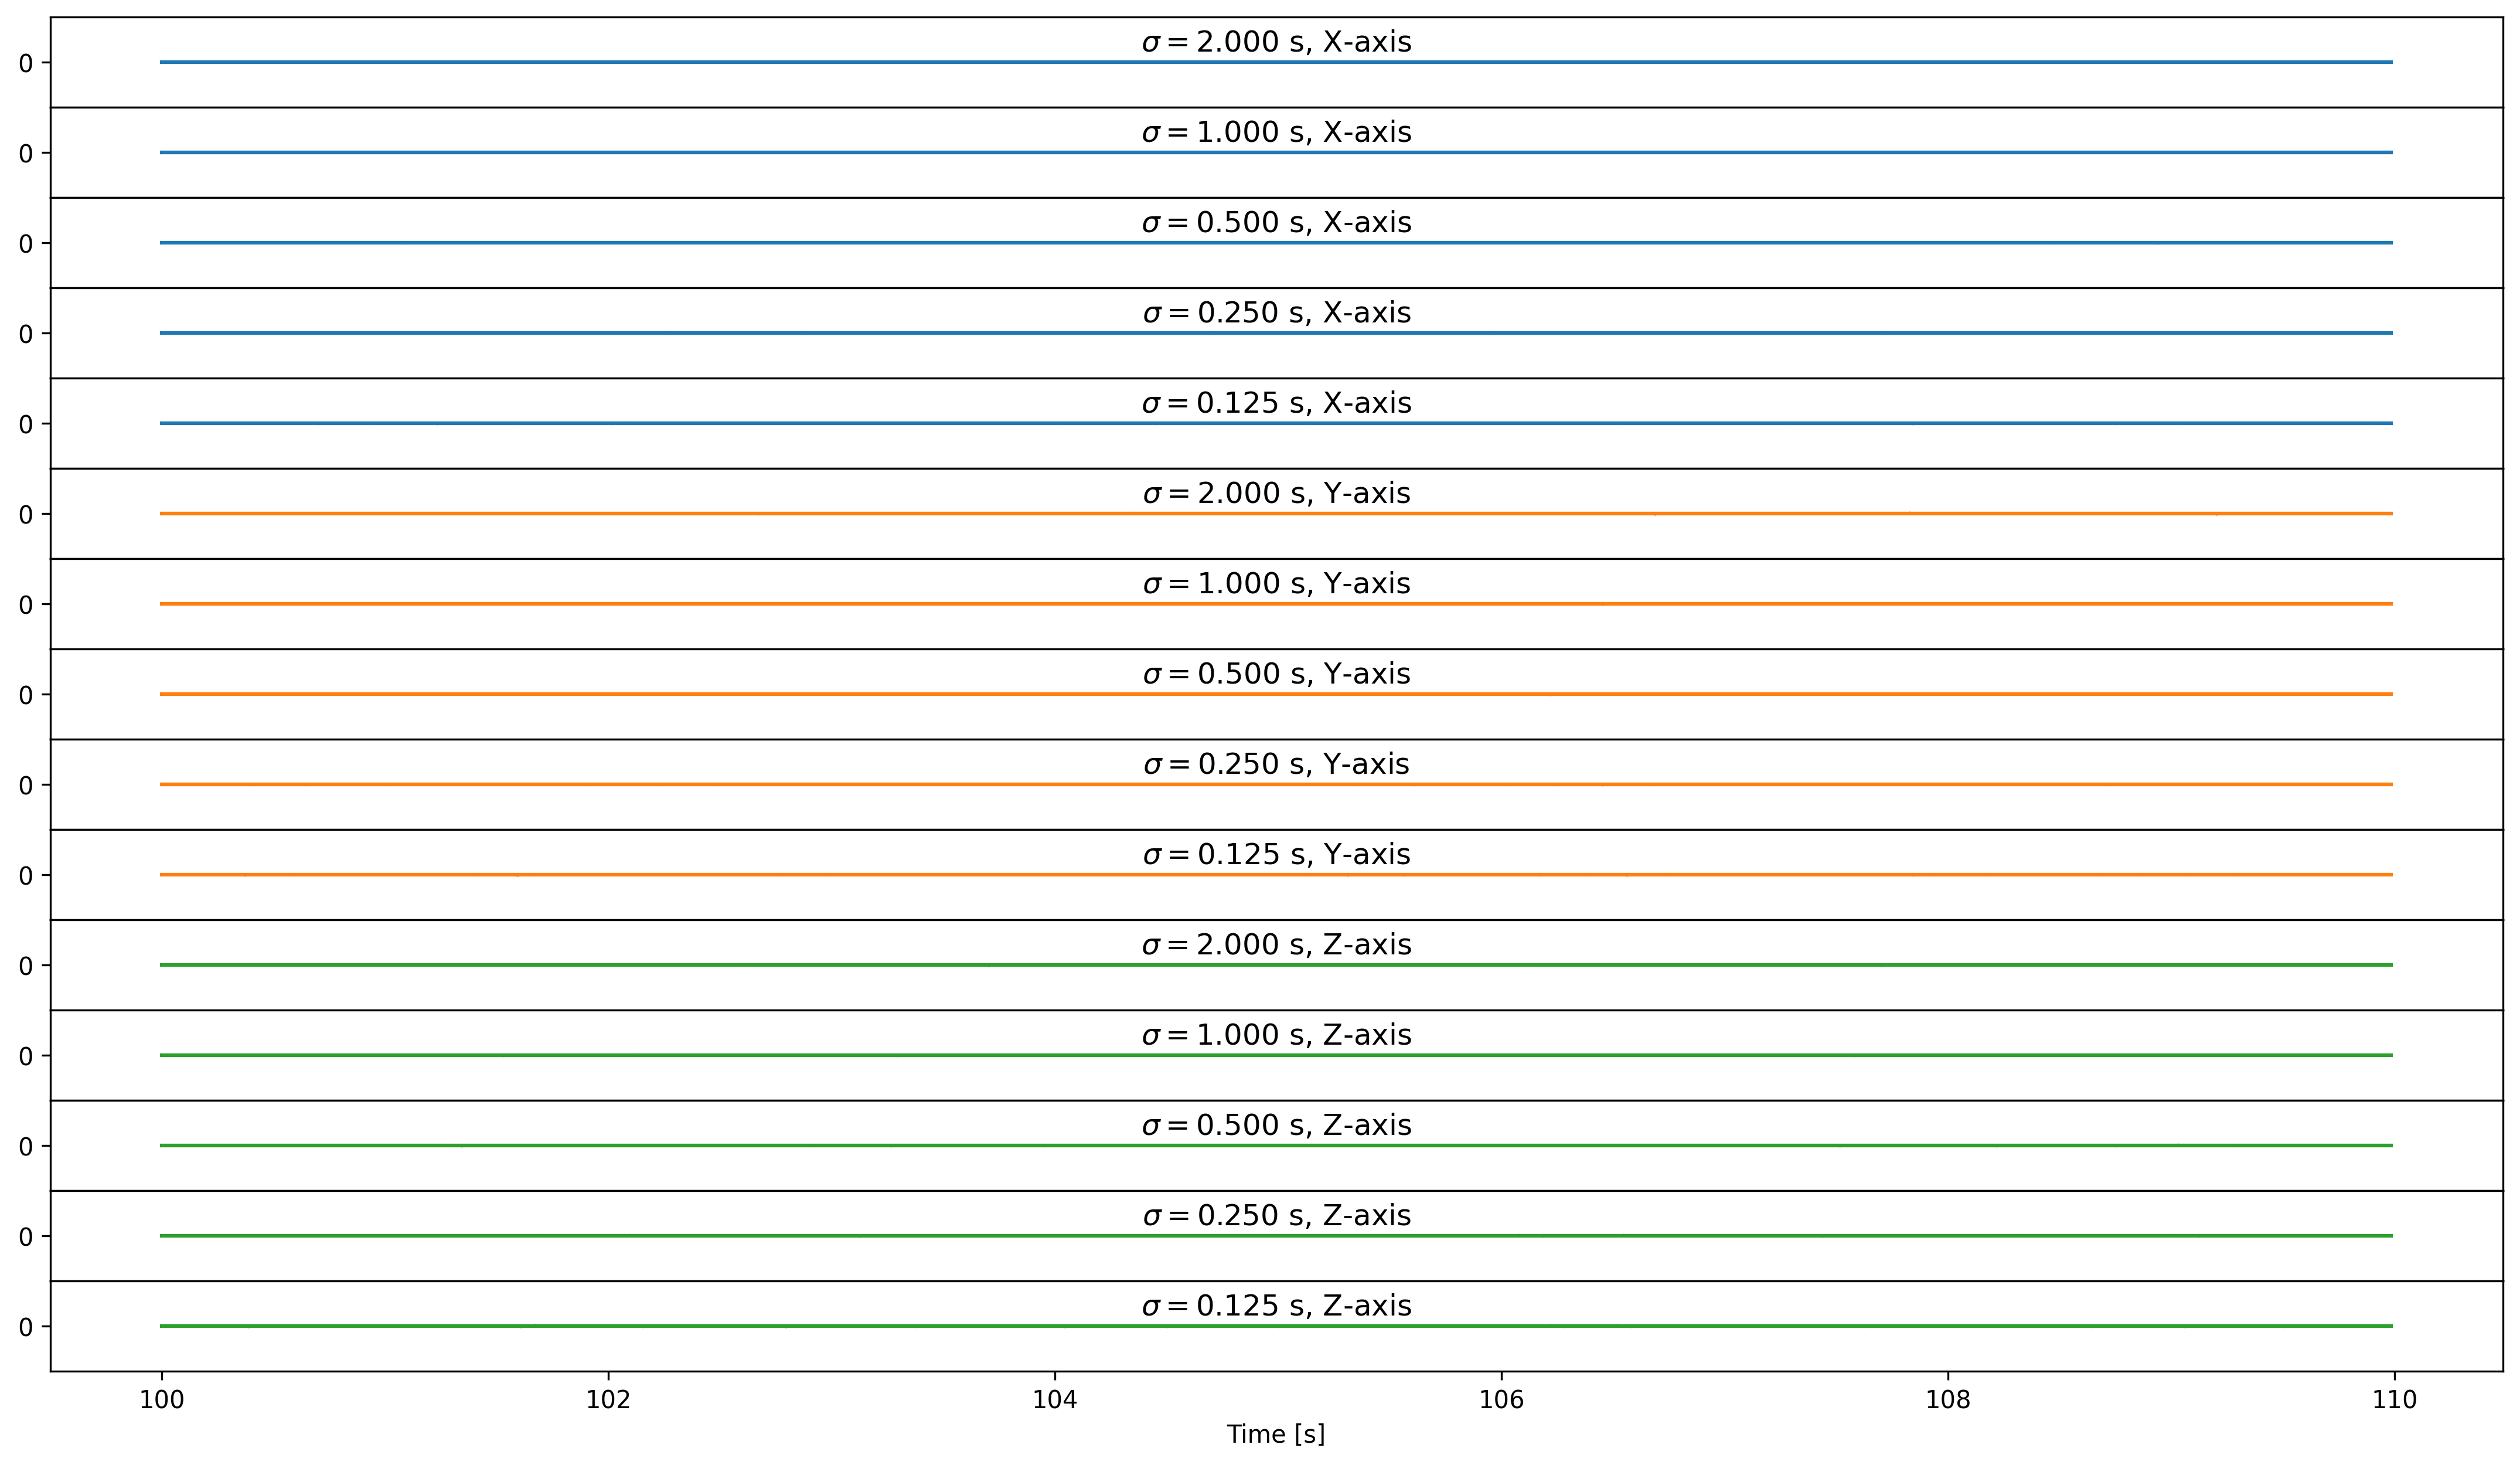

In [29]:
fig, ax = plt.subplots(15, 1, figsize=(18,10), sharey=True, sharex=True)
plt.subplots_adjust(hspace=0)

for i, (oL, axi) in enumerate(zip(outLabels, ax)):
    j = i % 5
    t1, t2 = 0, 640 # int(64*(1/2**j)), int(64*(10+1/2**j))
    x = dataFrameLeft['time'][t1:t2].to_numpy()
    y = dataFrameLeft[oL][t1:t2].to_numpy() * 9.81
    axi.stem(x, y, linefmt=f'C{i//5}', markerfmt='', basefmt=f'C{i//5}')
    axi.scatter(x[y!=0], y[y!=0], s=3*np.abs(y[y!=0]), c=f'C{i//5}')
    axi.set_title(rf'$\sigma=${[f"{2/2**j:.3f} s" for j in range(5)][i%5]}, {"XYZ"[i//5]}-axis', y=1.0, pad=-14)
    # axi.legend()
axi.set_xlabel('Time [s]')
axi.set_ylim(-15,15)
axi.set_yticks([0])

In [30]:
# outLabels = [f'spikes_{d}_{1/frequencies[j]:.2f}'
#              for d in ('xyz' if dim == 3 else '_') for j in range(numFilt)]
# dataFrameLeft[outLabels] = np.stack(out, 0).reshape(-1, dim * numFilt)

In [31]:
# # Plot spikes
# fig, ax = plt.subplots(1, 1, figsize=(18,6))
# sn.heatmap(dataFrameLeft[outLabels].T,
#             xticklabels=len(dataFrameLeft)//10,
#             yticklabels=True, cmap='Spectral', cbar=True, vmin=-1, vmax=1)
# ax.set_xticklabels([f"{dataFrameLeft.loc[int(t.get_text()), 'time'].item():.2f}"
#                     for t in ax.get_xticklabels()])
# # ax.set_xlim(1024,1400)

Reconstruct signal

In [32]:
maxS = int((sampleFreq / frequencies).max())
maxM = int(np.min([2 * maxS, len(dataFrameLeft)]))
delayMaxFilter = nimup.get_submodule('model.3.maxPooler').kernel_size[1]
for d in 'xyz':
    dataFrameLeft[f'rec_{d}'] = 0.0
    for j in range(numFilt):
        si = sampleFreq / frequencies[j]
        M = np.min([2 * si, len(dataFrameLeft)]).astype(int)
        impulse = signal.unit_impulse(maxM + delayMaxFilter, maxM // 2 - int(si) // 2)
        # nimup.get_submodule('model.2').filterBank.shape[0] // 2
        wavelet = signal.convolve(impulse, waveletFunc(si, si).flip(0), 'same')
        dataFrameLeft[f'rec_{d}'] += signal.convolve(dataFrameLeft[f'events_{d}_{1/frequencies[j]:.2f}'],
                                                     wavelet, 'same') / 2.5
        # plt.plot(wavelet)
    # dataFrameLeft[f'rec_{d}'] = integrate.cumulative_trapezoid(dataFrameLeft[f'rec_{d}'], dataFrameLeft['time'], initial=0)
    # dataFrameLeft[f'rec_{d}'] = np.sqrt(2 * np.abs(dataFrameLeft[f'rec_{d}']))
    # dataFrameLeft[f'rec_{d}'] = np.gradient(dataFrameLeft[f'rec_{d}'], dataFrameLeft['time']) 
    # dataFrameLeft[f'rec_{d}'] = signal.filtfilt(b, a, dataFrameLeft[f'rec_{d}'])

delaySamples = maxS // 2 + delayMaxFilter // 2

WARNING    /tmp/ipykernel_1062015/315698113.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrameLeft[f'rec_{d}'] = 0.0
 [py.warnings]
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrameLeft[f'rec_{d}'] = 0.0

WARNING    /tmp/ipykernel_1062015/315698113.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

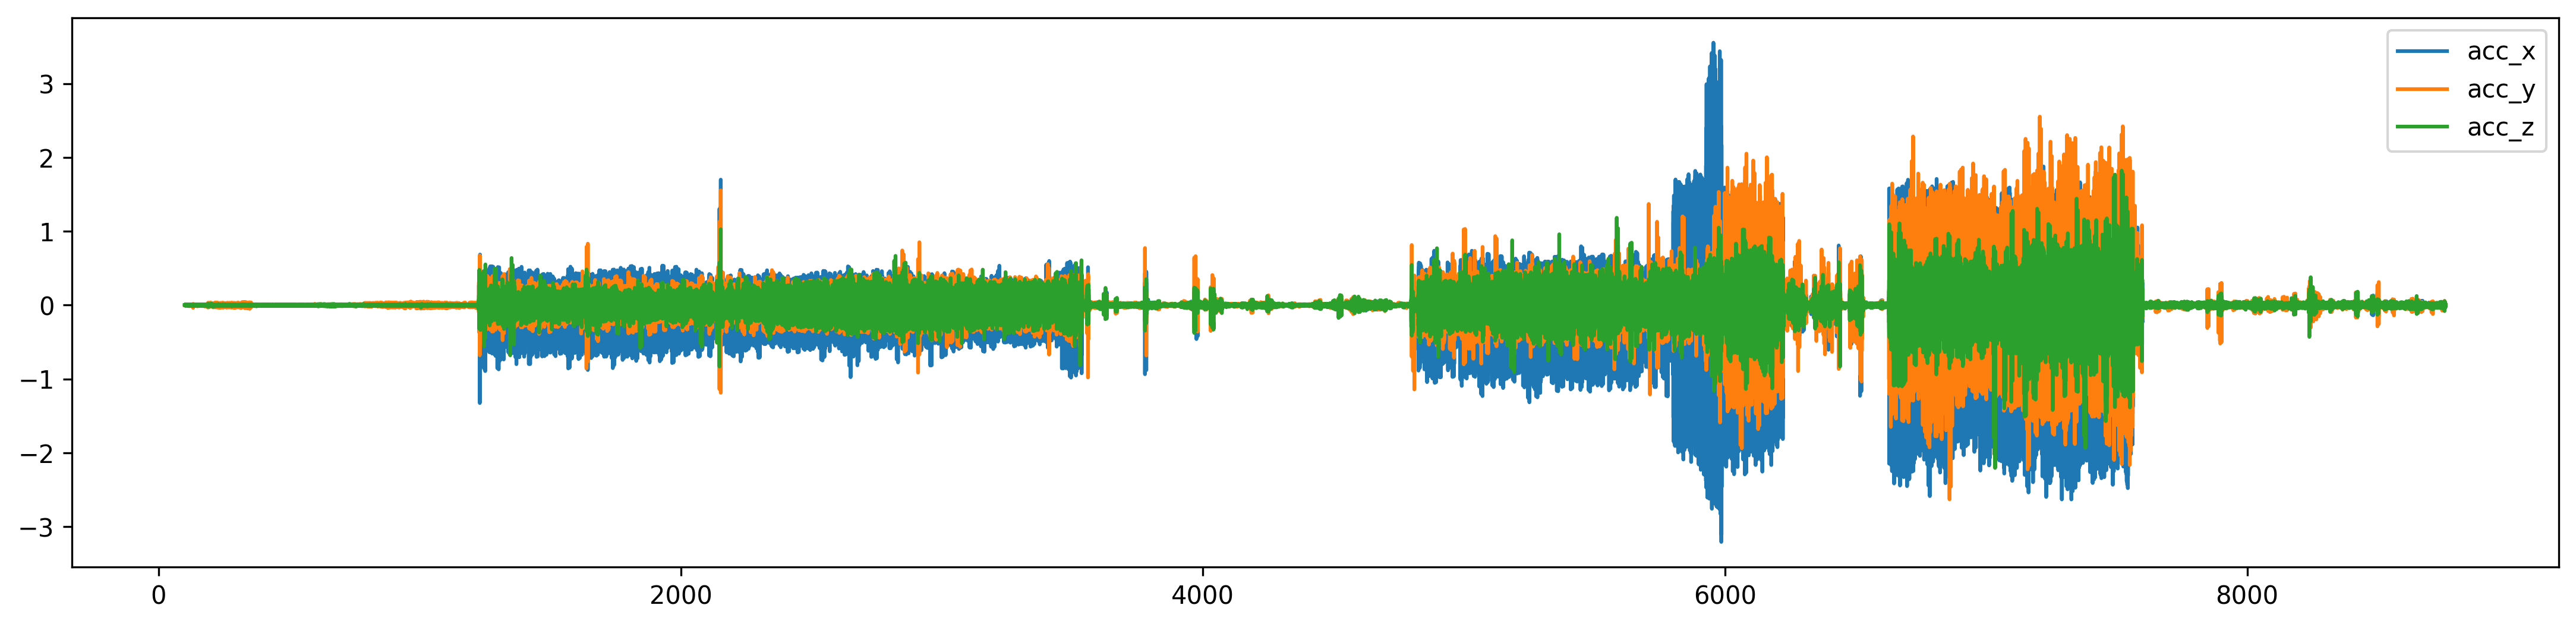

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(18,4), sharex=True)

ax.plot(dataFrameLeft['time'], dataFrameLeft[[f'acc_{d}' for d in 'xyz']], label=[f'acc_{d}' for d in 'xyz'])
ax.legend()

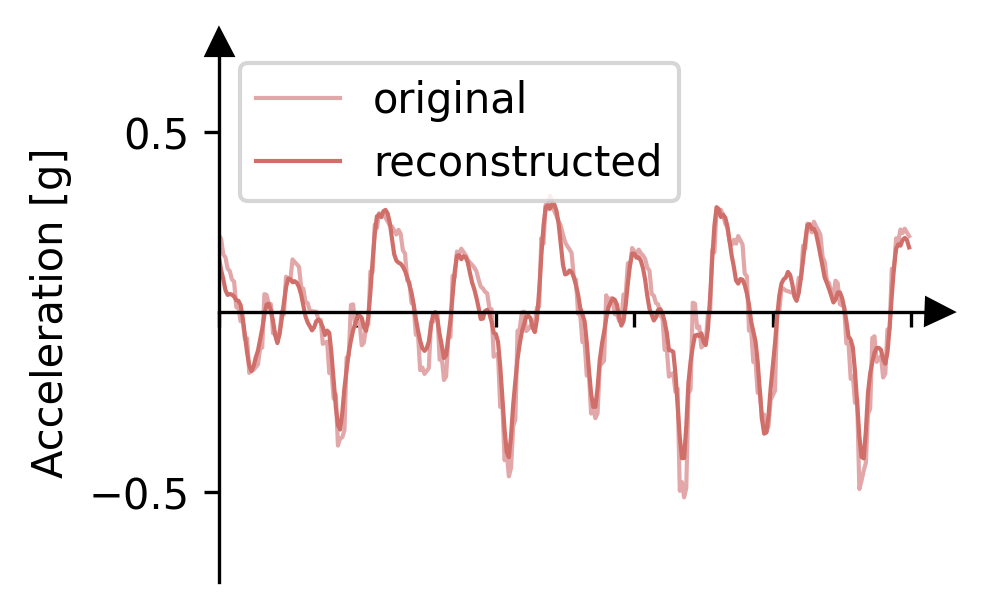

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(3,2), sharex=True, sharey=True)
fig.subplots_adjust(bottom=0.05, top=0.95, left=0.15, right=0.95, hspace=0)

ax.plot(dataFrameLeft['time'][2000*64:2005*64]-2100, dataFrameLeft[f'rawacc_x'][2000*64:2005*64], label='original', color=f'#e2a7a8ff', lw=1)
ax.plot(dataFrameLeft['time'][2000*64:2005*64]-2100, dataFrameLeft[f'rec_x'][2000*64:2005*64], label='reconstructed', color=f'#d06f6aff', lw=1)
ax.set_ylabel(f'Acceleration [g]')
ax.legend(loc='upper left')

# ax.set_xlabel('Time [s]', loc='right')
ax.set_xlim(0,5.2)
ax.set_ylim(-.75,.75)
ax.set_xticks(np.arange(6) ,[None]*6)
ax.set_yticks([-0.5,.5])

ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

fig.savefig('../results/nimu-reconstructed.pdf', dpi=150)

8659.9375
0.08891604425793298 5.786707212197078 3.961027591761509 1.4609106041656406


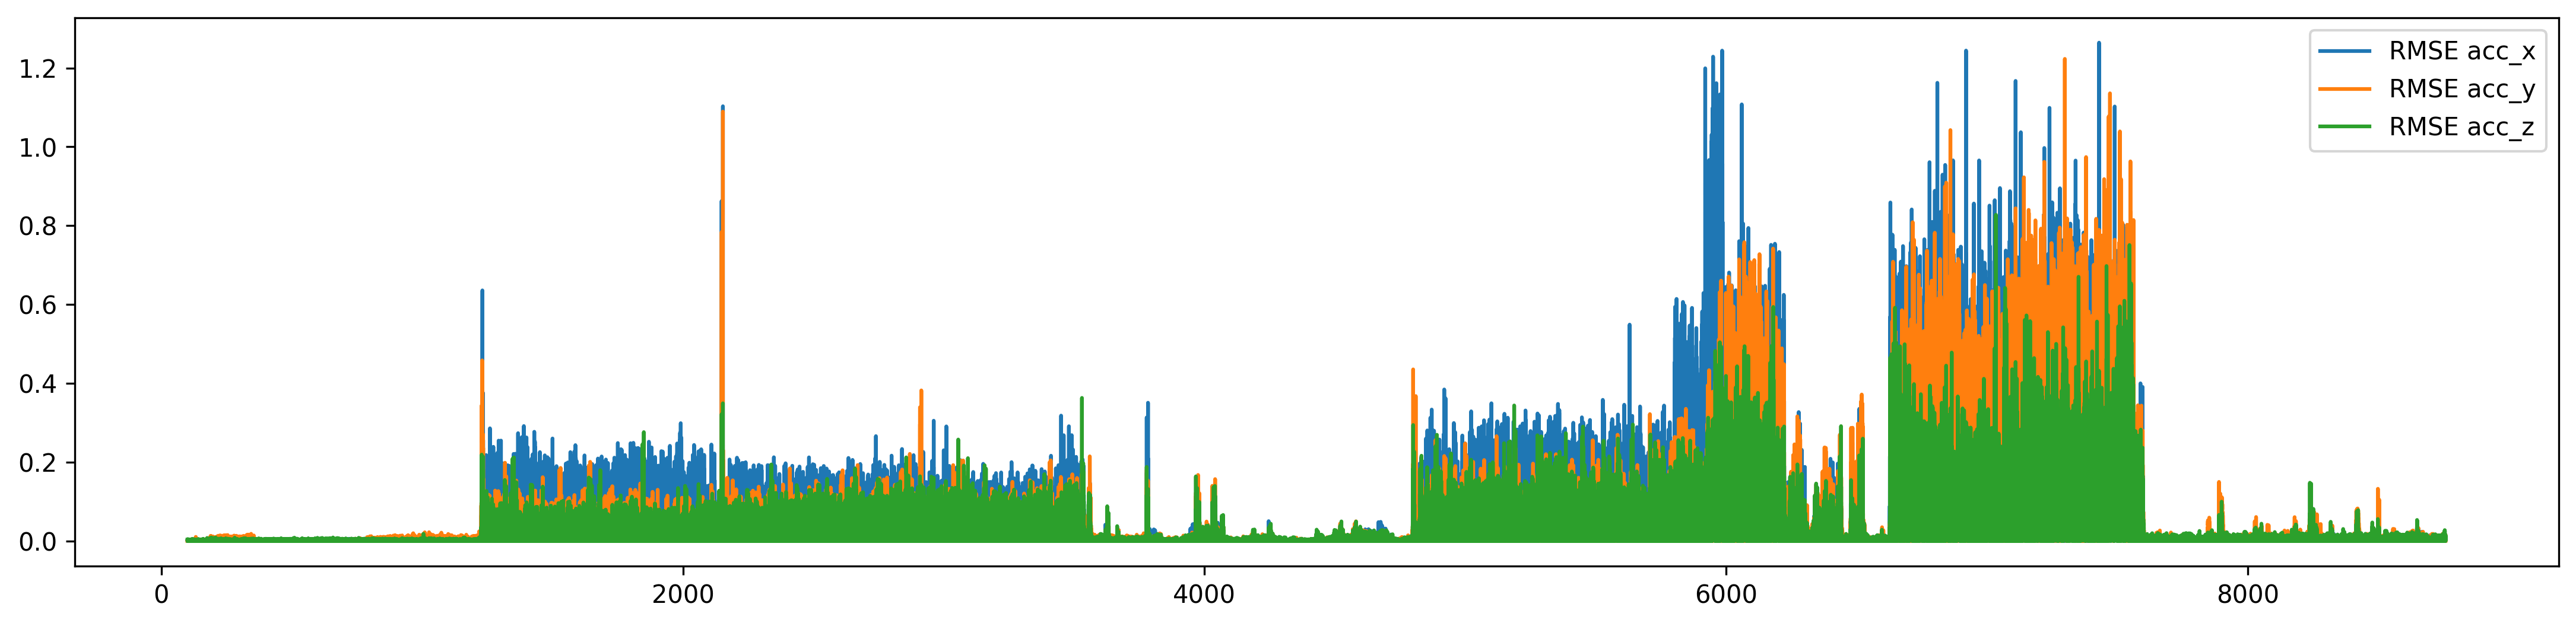

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(18,4))

for d in 'xyz':
    ax.plot(dataFrameLeft['time'].to_numpy()[:-delaySamples],
            np.abs(dataFrameLeft[f'acc_{d}'].to_numpy()[:-delaySamples] -
                   dataFrameLeft[f'rec_{d}'].to_numpy()[:-delaySamples]),
            label=f'RMSE acc_{d}')
ax.legend()

inp = dataFrameLeft[[f'acc_{d}' for d in 'xyz']].to_numpy()[:-delaySamples]
diff = (dataFrameLeft[[f'acc_{d}' for d in 'xyz']].to_numpy()[:-delaySamples] -
       dataFrameLeft[[f'rec_{d}' for d in 'xyz']].to_numpy()[:-delaySamples])
spk = dataFrameLeft[[f'events_{d}_{1/frequencies[j]:.2f}' for d in ('xyz' if dim == 3 else '_')
                     for j in range(numFilt)]].to_numpy()[:-delaySamples]

nrmse = np.sqrt(((diff) ** 2).mean()) * 9.81 / 9
snr = 10 * np.log10(np.sqrt((inp ** 2).mean()) / np.sqrt((diff ** 2).mean()))
spks = (spk != 0).mean() * 64
snrperspks = snr / spks
print(len(dataFrameLeft)/64)
print(nrmse, snr, spks, snrperspks)

In [36]:
from rockpool.devices.xylo.syns63300 import IMUIFSim
from rockpool.devices.xylo.syns63300.imuif import FilterBank
from rockpool.devices.xylo.syns63300 import Quantizer

input_data = dataFrameLeft[[f'rawacc_{d}' for d in 'xyz']].to_numpy(dtype=float) #/ 9.81
input_data = np.clip(input_data / 2, -1+1e-5, 1-1e-5)
quantizer = Quantizer(shape=3, num_bits=16)
Q_data, _, _ = quantizer(input_data)

# Using default values for frequency bands
frequencies = [(sampleFreq / 200 * fi, sampleFreq / 200 * fj)
               for fi, fj in [(1,2),(2,4),(4,8),(8,16),(16,32)]]
fb = FilterBank.from_specification((3, 15), *(frequencies * 3))
mod = IMUIFSim(bypass_jsvd=True, sampling_freq=sampleFreq, select_iaf_output=True)#, filter_list=fb._filters)

rec_data, _, r_d = mod.model[0](Q_data, record = True)
rec_data = rec_data[0].astype(int).T.reshape(3,5,-1).sum(1).T / 2 ** 15
spikes , _, r_d = mod(Q_data, record = True)

nrmse = np.sqrt(((input_data - rec_data) ** 2).mean()) * 9.81 / 9
snr = 10 * np.log10(np.sqrt((input_data ** 2).mean()) / np.sqrt(((input_data - rec_data) ** 2).mean()))
spks = (spikes != 0).mean() * 64
snrperspks = snr / spks

print(nrmse, snr, spks, snrperspks)

0.07783336109628475 3.3786665583246127 26.785836117947348 0.12613631112529658


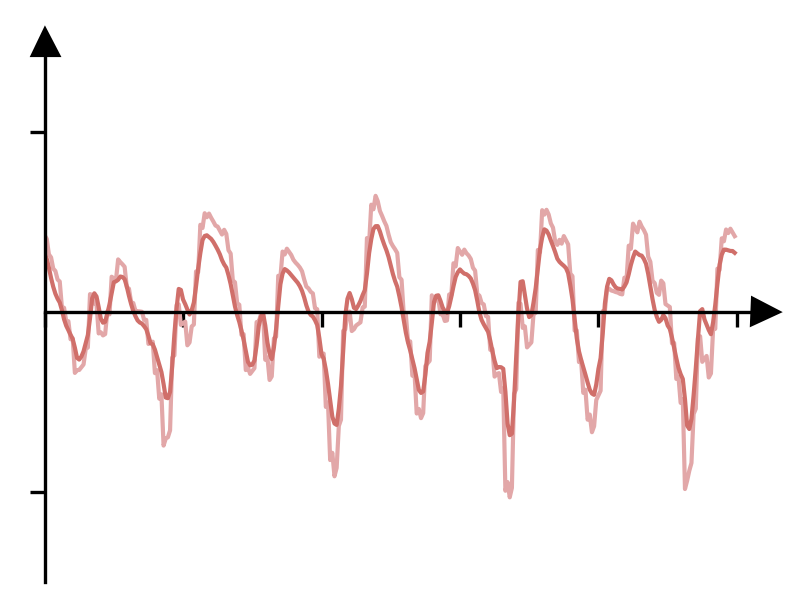

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(3,2), sharex=True, sharey=True)
fig.subplots_adjust(bottom=0.05, top=0.95, left=0.15, right=0.95, hspace=0)

ax.plot(dataFrameLeft['time'][2000*64:2005*64]-2100, dataFrameLeft[f'rawacc_x'][2000*64:2005*64], label='original', color=f'#e2a7a8ff', lw=1)
ax.plot(dataFrameLeft['time'][2000*64:2005*64]-2100, rec_data[2000*64:2005*64,0], label='reconstructed', color=f'#d06f6aff', lw=1)
# ax.set_ylabel(f'Acceleration [g]')
# ax.legend(loc='upper left')

# ax.set_xlabel('Time [s]', loc='right')
ax.set_xlim(0,5.2)
ax.set_ylim(-.75,.75)
ax.set_xticks(np.arange(6) ,[None]*6)
ax.set_yticks([-0.5,.5], [None]*2)

ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

fig.savefig('../results/xylo-reconstructed.pdf', dpi=150)

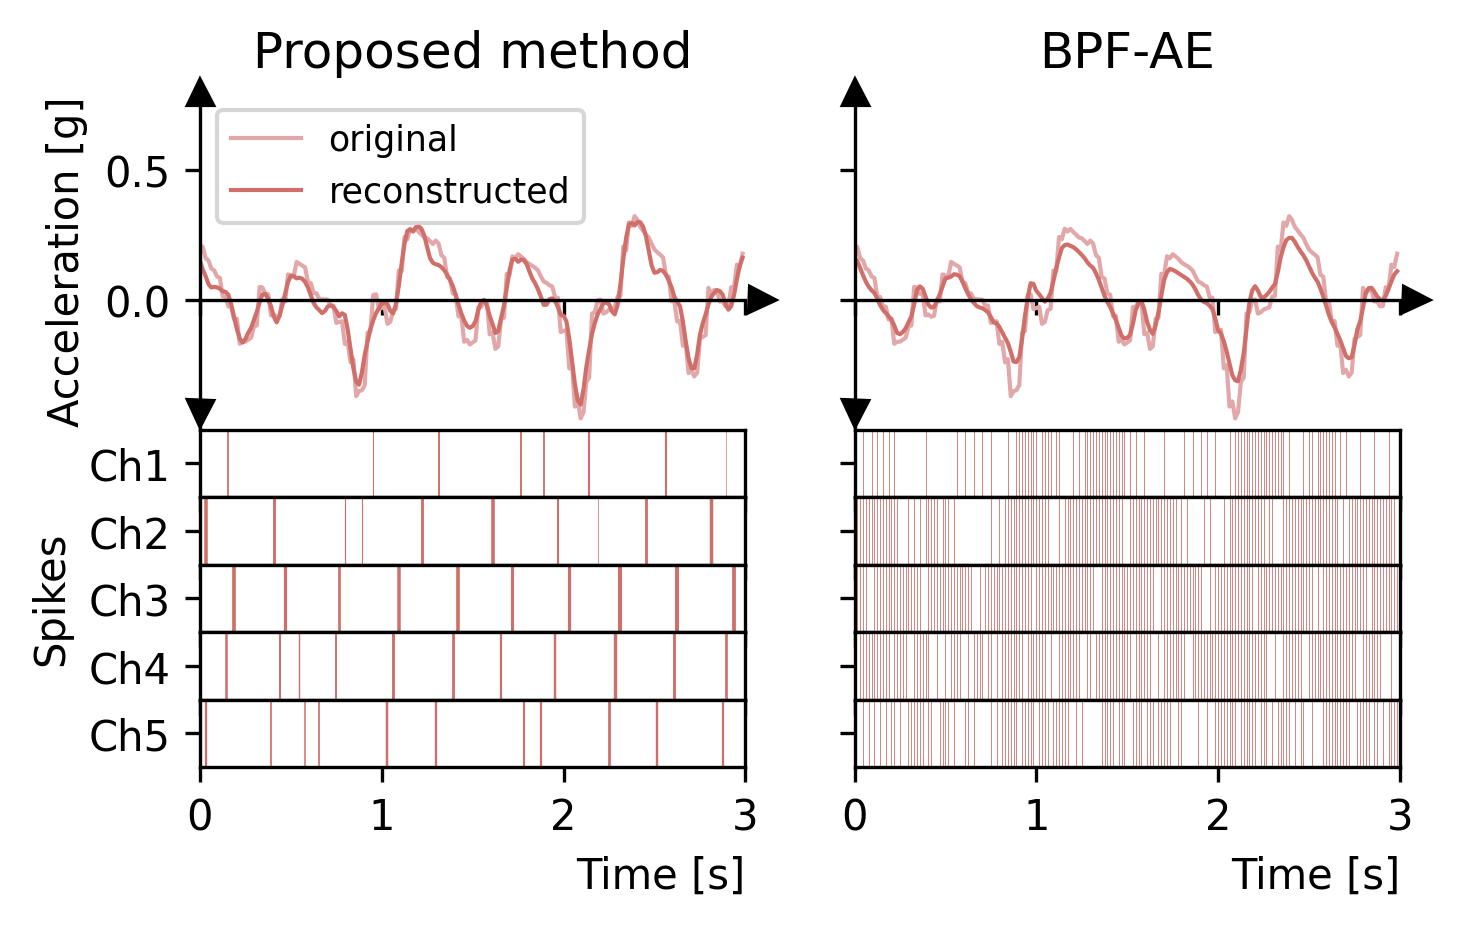

In [96]:
fig, ax = plt.subplots(6, 2, figsize=(5,3), sharex=True, sharey='row', gridspec_kw={'height_ratios': [5]+[1]*5})
fig.subplots_adjust(bottom=0.15, top=0.9, left=0.15, right=0.95, hspace=0)

ax[0,0].plot(dataFrameLeft['time'][2000*64:2003*64]-2100, dataFrameLeft[f'rawacc_x'][2000*64:2003*64], label='original', color=f'#e2a7a8ff', lw=1)
ax[0,0].plot(dataFrameLeft['time'][2000*64:2003*64]-2100, dataFrameLeft[f'rec_x'][2000*64:2003*64], label='reconstructed', color=f'#d06f6aff', lw=1)
ax[0,1].plot(dataFrameLeft['time'][2000*64:2003*64]-2100, dataFrameLeft[f'rawacc_x'][2000*64:2003*64], color=f'#e2a7a8ff', lw=1)
ax[0,1].plot(dataFrameLeft['time'][2000*64:2003*64]-2100, rec_data[2000*64:2003*64,0], color=f'#d06f6aff', lw=1)
for i in range(5):
    N = 3 * 64
    x = 3 / N * np.arange(N)
    y1 = dataFrameLeft[[c for c in dataFrameLeft.columns if 'events_x' in c][i]][2000*64:2003*64]
    y2 = spikes.reshape(-1,15)[2000*64:2003*64,i]
    ax[i+1,0].vlines(x=x[y1!=0], ymin=0, ymax=10, colors='#d06f6aff', linewidth=(np.abs(y1)**(1/2))[y1!=0])
    ax[i+1,1].vlines(x=x[y2!=0], ymin=0, ymax=10, colors='#d06f6aff', linewidth=(y2/5)[y2!=0])
    ax[i+1,0].set_yticks([5], [f'Ch{i+1}'])
    ax[i+1,0].set_ylim(0,10)

for j in range(2):
    ax[-1,j].set_xlabel('Time [s]', loc='right')
    ax[0,j].set_xlim(-.0,3.)
    ax[0,j].set_ylim(-.5,.8)
    ax[0,j].set_xticks(np.arange(4))
    ax[0,j].set_yticks([0,.5])
    
    ax[0,j].spines["left"].set_position(("data", 0))
    ax[0,j].spines["bottom"].set_position(("data", 0))
    ax[0,j].spines["top"].set_visible(False)
    ax[0,j].spines["right"].set_visible(False)
    ax[0,j].plot(1.03, 0, ">k", transform=ax[0,j].get_yaxis_transform(), clip_on=False)
    ax[0,j].plot(0, 1, "^k", transform=ax[0,j].get_xaxis_transform(), clip_on=False)
    ax[0,j].plot(0, 0.05, "vk", transform=ax[0,j].get_xaxis_transform(), clip_on=False)

ax[0,0].legend(loc=2, fontsize='small')
ax[0,0].set_ylabel(f'Acceleration [g]')
ax[3,0].set_ylabel(f'Spikes')
ax[0,0].set_title('Proposed method')
ax[0,1].set_title('BPF-AE')

fig.savefig('../results/reconstructed-and-spikes.pdf', dpi=150)

# Sweep XyloIMU vs our method

XyloIMU

In [9]:
from rockpool.devices.xylo.syns63300 import IMUIFSim
from rockpool.devices.xylo.syns63300.imuif import FilterBank
from rockpool.devices.xylo.syns63300 import Quantizer
from scipy import signal

# - Load a dummy IMU sample
raw_data = np.loadtxt(f'../data/Subject001_left_global_acc.csv', delimiter=',')[:,:4] - np.array([[0,0,0,9.81]])
sampleFreq = 512

b, a = signal.butter(4, 0.1 / (sampleFreq / 2), btype='highpass')
raw_data[:,1:4] = signal.filtfilt(b, a, raw_data[:,1:4] / 9.81, axis=0)

input_data = np.copy(raw_data)

b, a = signal.butter(4, 20.0 / (sampleFreq / 2), btype='lowpass')
input_data = signal.filtfilt(b, a, input_data[:,1:4], axis=0)

input_data = input_data[(raw_data[:,0]>=100)*(raw_data[:,0]<200)]
raw_data = raw_data[(raw_data[:,0]>=100)*(raw_data[:,0]<200)][:,1:4]

quantizer = Quantizer(shape=3, scale=0.49, num_bits=16)
Q_data, _, _ = quantizer(raw_data)

In [10]:
raw_data.shape, input_data.shape

((51200, 3), (51200, 3))

In [ ]:
df = pd.DataFrame(columns=['f0', 'f1', 'nrmse', 'snr', 'spks', 'snr per spks'])

for f0 in np.logspace(math.log10(1e-2), math.log10(3e-1), 20, base=10):
    for f1 in np.logspace(math.log10(1e0), math.log10(3e1), 20, base=10):

        freqs = np.logspace(math.log10(f0), math.log10(f1), 6, base=10)
        freqs = [(fi, fj, sampleFreq) for fi, fj in zip(freqs[:-1], freqs[1:])]
        # freqs = [(0.01, 0.05, sampleFreq), (0.05, 0.25, sampleFreq), (0.25, 1.25, sampleFreq),
        #          (1.25, 6.25, sampleFreq), (6.25, 31.25, sampleFreq)]

        # - Create an IMUIFSim module
        fb = FilterBank.from_specification((3, 15), *(freqs * 3))
        mod = IMUIFSim(bypass_jsvd=True, sampling_freq=512, select_iaf_output=True, filter_list=fb._filters)

        rec_data, _, r_d = mod.model[0](Q_data, record = True)
        spikes , _, r_d = mod(Q_data, record = True)

        nrmse = np.sqrt(((input_data - rec_data[0].astype(int).T.reshape(3,5,-1).sum(1).T / 2 ** 15) ** 2).mean()) * 9.81 / 9
        snr = np.sqrt((input_data ** 2).mean()) / np.sqrt(((input_data - rec_data[0].astype(int).T.reshape(3,5,-1).sum(1).T / 2 ** 15) ** 2).mean())
        spks = spikes.mean()
        snrperspks = snr / spks
        
        df.loc[len(df)] = [f0, f1, nrmse, snr, spks, snrperspks]

(0.0, 10.0)

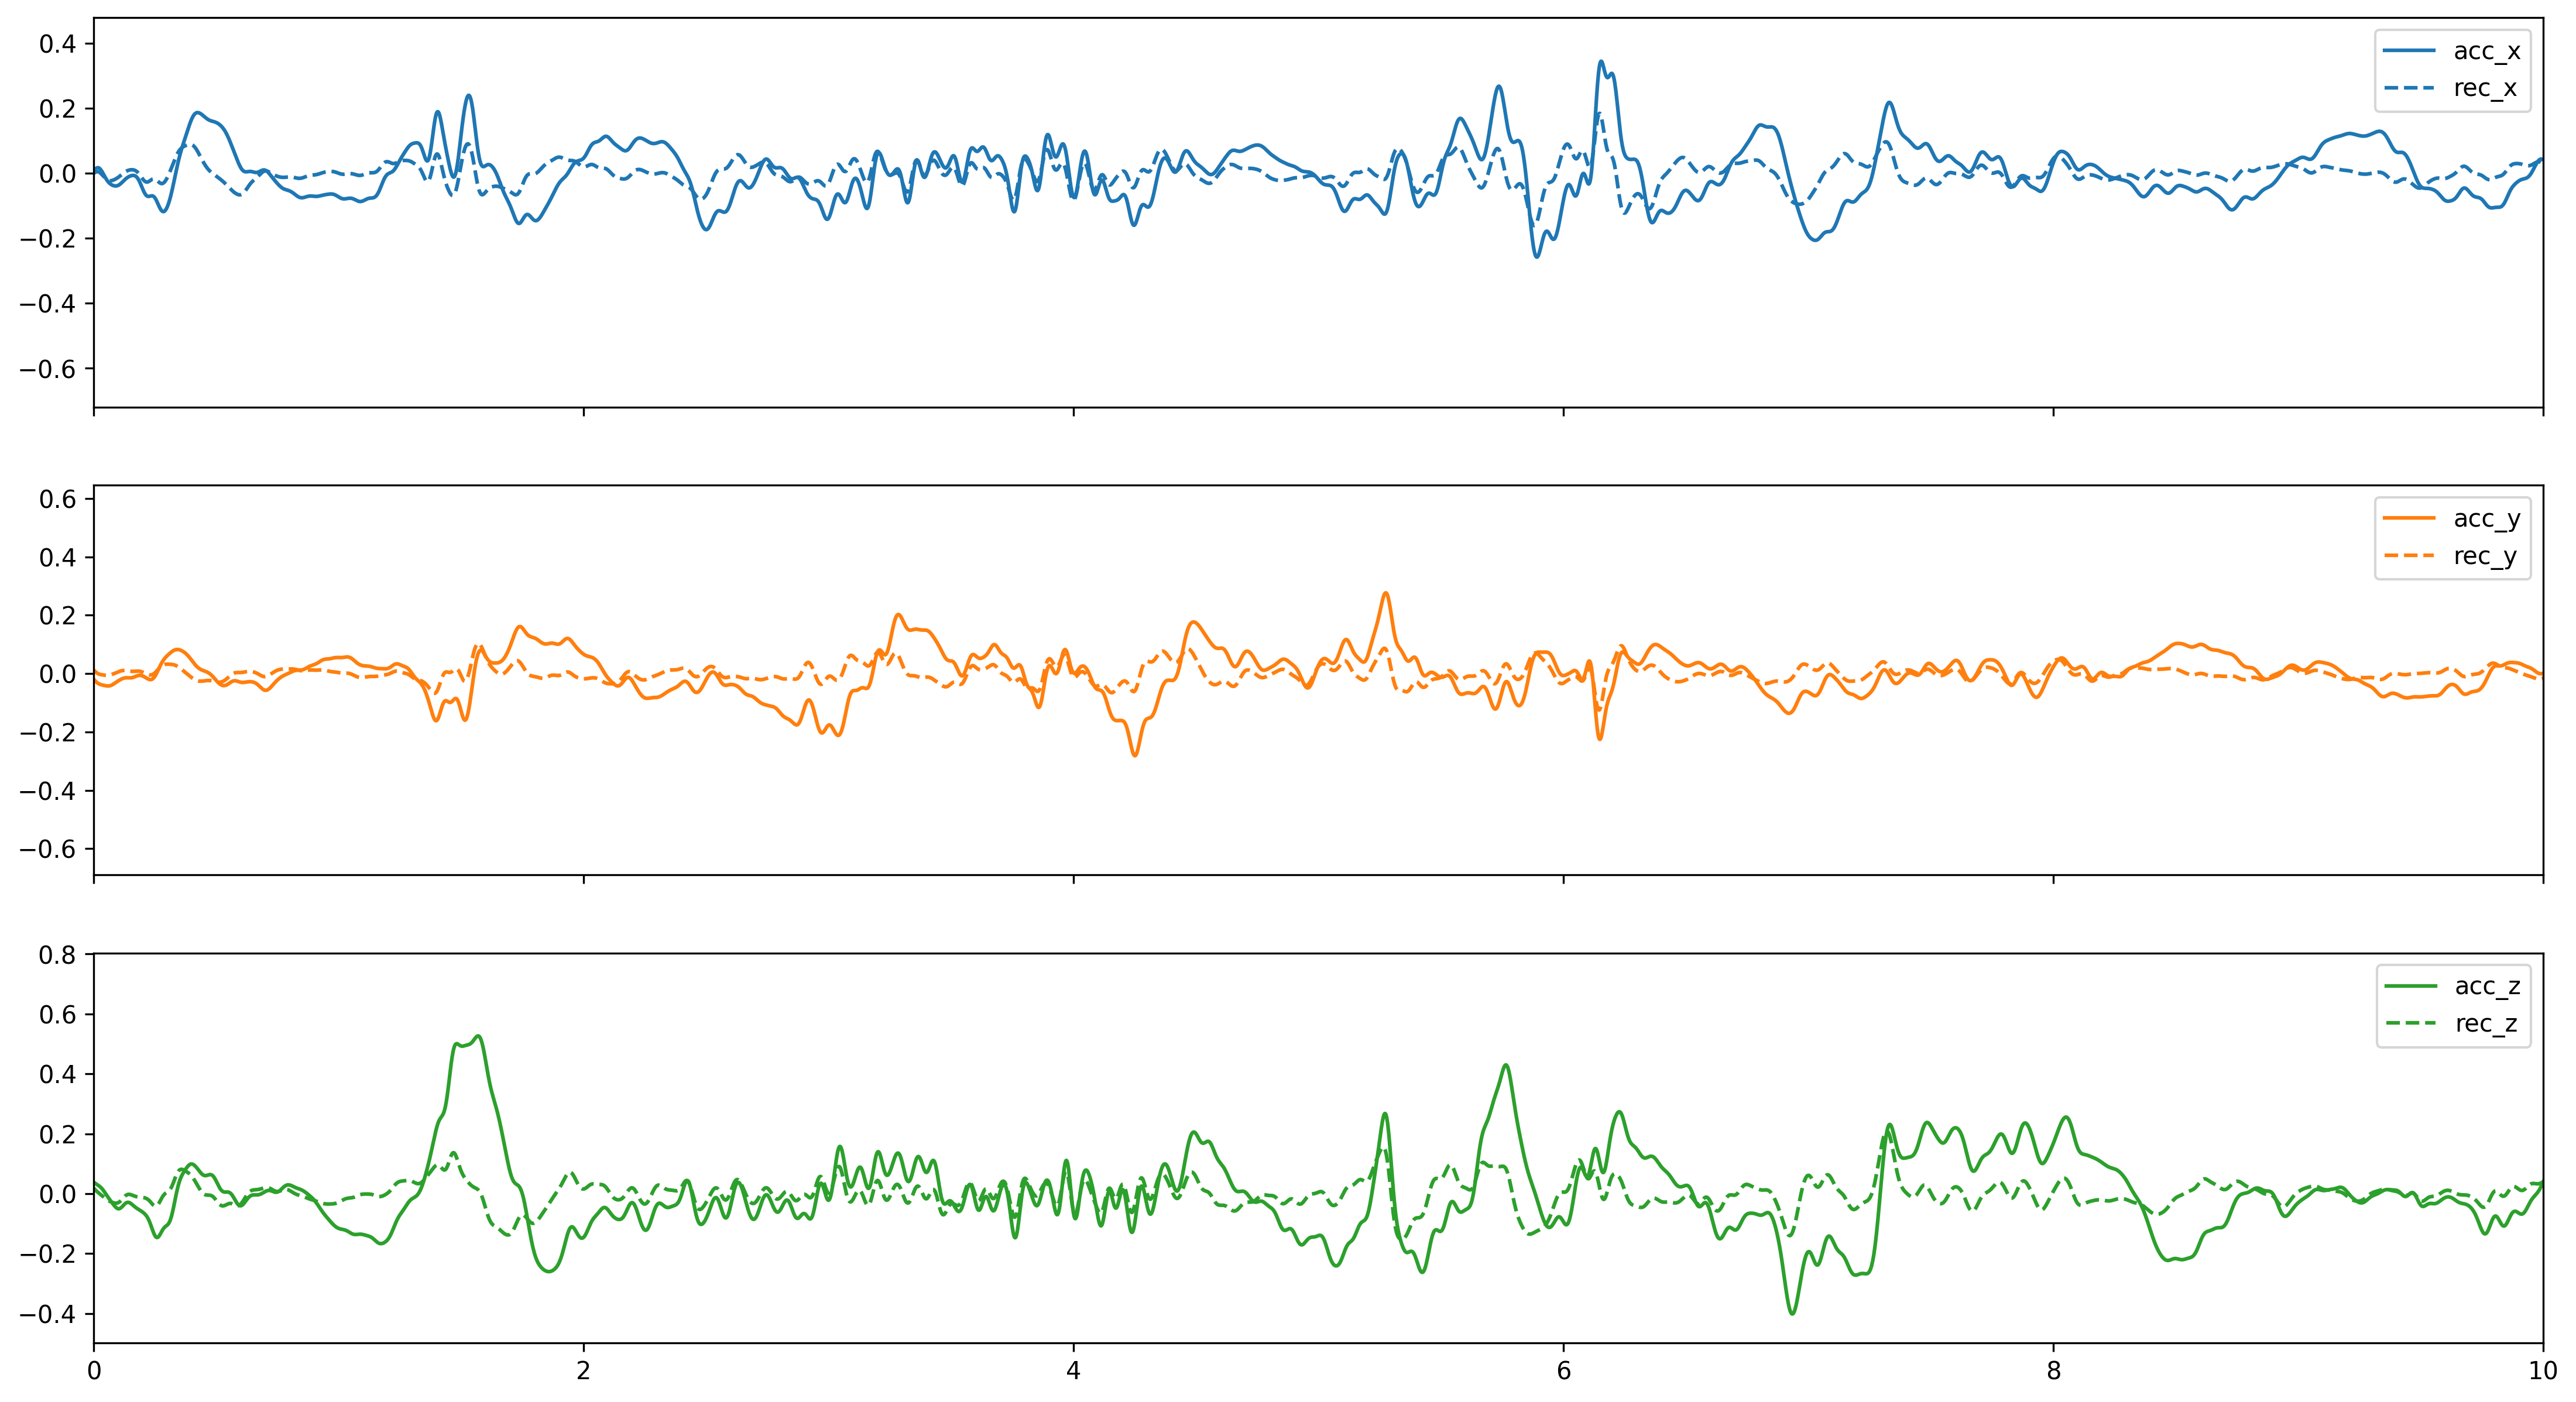

In [36]:
fig, ax = plt.subplots(3, 1, figsize=(18,10), sharex=True)

for i, (axi, d) in enumerate(zip(ax, 'xyz')):
    axi.plot(np.arange(len(raw_data))/512., raw_data[:,i], '-', label=f'acc_{d}', color=f'C{i}')
    axi.plot(np.arange(len(raw_data))/512., rec_data[0].astype(int).T.reshape(3,5,-1).sum(1).T[:,i] / 2 ** 15, '--', label=f'rec_{d}', color=f'C{i}')
    axi.legend()

axi.set_xlim(0,10)

In [9]:
f0, f1 = 1 * sampleFreq / 200, 32 * sampleFreq / 200 # 0.01, 20.971756515126067

freqs = np.logspace(math.log10(f0), math.log10(f1), 6, base=10)
freqs = [(fi, fj, sampleFreq) for fi, fj in zip(freqs[:-1], freqs[1:])]
print(freqs)
# freqs = [(1, 2, 200), (2, 4, 200), (4, 8, 200), (8, 16, 200), (16, 32, 200)]

for fi, fj, sF in freqs:
    # - Create an IMUIFSim module
    b, a = signal.butter(1, [fi / (sF / 2), fj / (sF / 2)], btype='bandpass')
    print(b, a)
for fi, fj, sF in freqs:
    # - Create an IMUIFSim module
    b, a = signal.butter(1, [fi / (sF / 2), fj / (sF / 2)], btype='bandpass')
    b_norm = b / np.abs(b[0])
    # compute the closest power of 2 larger that than b[0]
    B_b = int(np.log2(1 / abs(b[0])))
    B_wf = 9 - 1
    B_af = 16 - B_b - 1
    B_w = 16 + 9 + B_wf

    # quantize the a-taps of the filter
    a_taps = (2 ** (B_af + B_b) * a).astype(np.int64)
    a1 = a_taps[1]
    a2 = a_taps[2]
    scale_out = b[0] * (2**B_b)
    print(B_b, B_wf, B_af, B_w, a1, a2, scale_out)

[(0.32, 0.6399999999999999, 64), (0.6399999999999999, 1.2799999999999998, 64), (1.2799999999999998, 2.559999999999999, 64), (2.559999999999999, 5.119999999999998, 64), (5.119999999999998, 10.239999999999998, 64)]
[ 0.01546629  0.         -0.01546629] [ 1.         -1.96712419  0.96906742]
[ 0.03046875  0.         -0.03046875] [ 1.         -1.93140991  0.93906251]
[ 0.0591907  0.        -0.0591907] [ 1.         -1.85194434  0.88161859]
[ 0.11216024  0.         -0.11216024] [ 1.         -1.66410704  0.77567951]
[ 0.20430082  0.         -0.20430082] [ 1.         -1.19770766  0.59139835]
6 8 9 33 -64458 31754 0.9898426497986152
5 8 10 33 -63288 30771 0.9749999069201221
4 8 11 33 -60684 28888 0.9470512610944865
3 8 12 33 -54529 25417 0.8972819558015471
2 8 13 33 -39246 19378 0.8172032972010581


In [41]:
np.log2(1/0.00177217)

9.140267279870136

In [26]:
df.to_csv('./xyloIMU_metrics_logarithmicfreq.csv')

In [33]:
df = pd.read_csv('./xyloIMU_metrics_logarithmicfreq.csv')
df['snr per spks'] = 10 * np.log10(df['snr per spks'])
df['snr'] = 10 * np.log10(df['snr'])
df.f0 = np.round(df.f0, 3)
df.f1 = np.round(df.f1, 1)
f0, f1 = tuple(df[df['snr per spks']  == df['snr per spks'].max()][['f0','f1']].to_numpy().flatten())
np.linspace(f0, f1, 6)

array([1.0000e-02, 4.2080e+00, 8.4060e+00, 1.2604e+01, 1.6802e+01,
       2.1000e+01])

In [34]:
df[df['snr per spks'] > 0.95 * df['snr per spks'].max()]

,Unnamed: 0,f0,f1,nrmse,snr,spks,snr per spks
17,17,0.010,21.0,0.008416,10.240228,0.398911,11.631603
18,18,0.010,25.1,0.012876,9.406274,0.372010,11.145001
37,37,0.012,21.0,0.009350,10.048311,0.415035,11.439827
56,56,0.014,17.5,0.009525,10.013660,0.412346,11.423545
76,76,0.017,17.5,0.011234,9.691565,0.405499,11.217089


<Axes: xlabel='f1', ylabel='f0'>

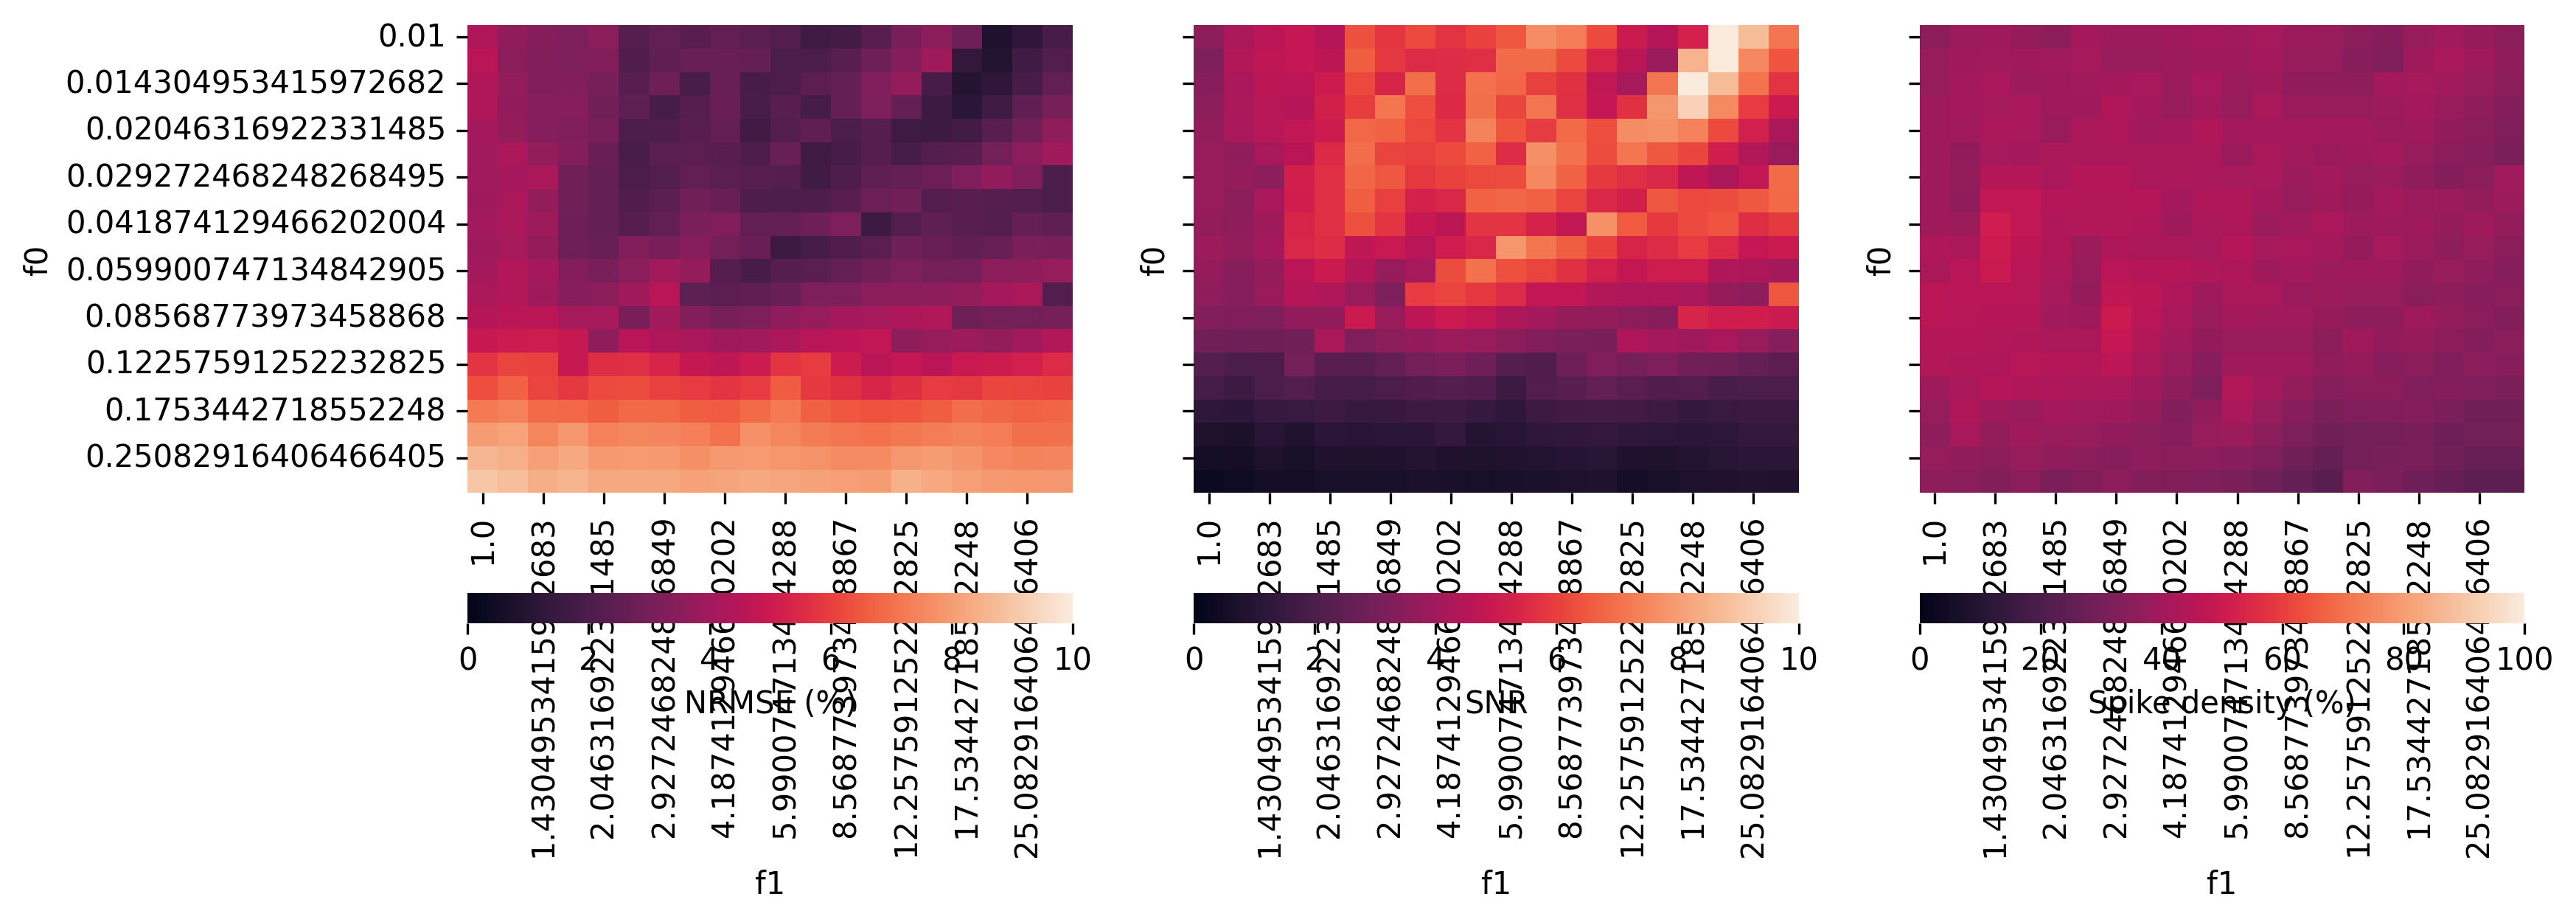

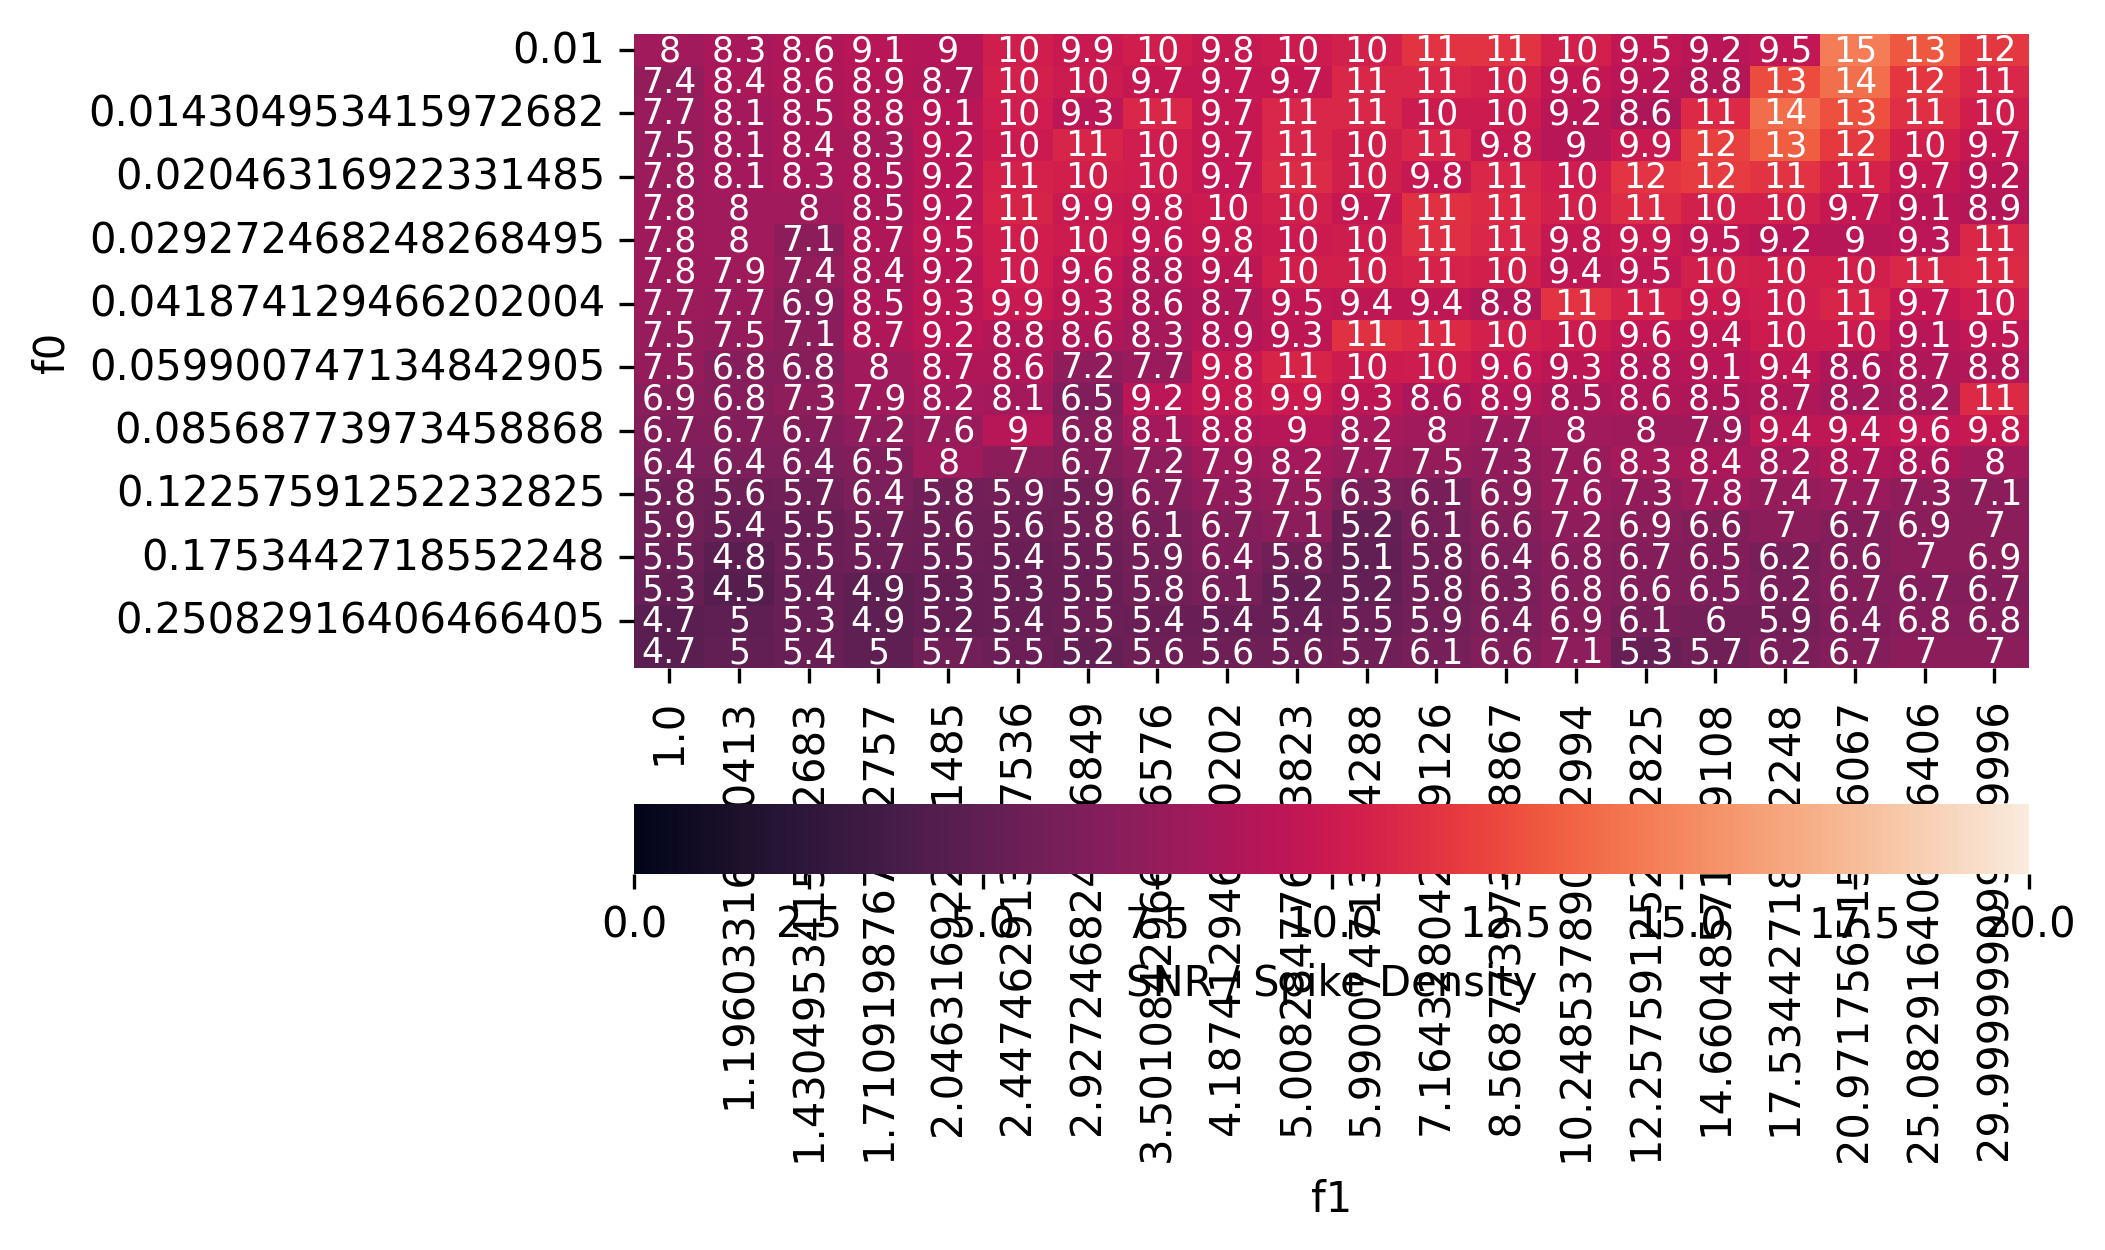

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(12,4), sharex=True, sharey=True)

sn.heatmap(df.pivot(index='f0', columns='f1', values='nrmse') * 100, vmin=0, vmax=10, annot=False, ax=ax[0], annot_kws={'size':'x-small'}, cbar_kws={'location':'bottom', 'label':'NRMSE (%)'})
sn.heatmap(df.pivot(index='f0', columns='f1', values='snr'), vmin=0, vmax=10, annot=False, ax=ax[1], annot_kws={'size':'x-small'}, cbar_kws={'location':'bottom', 'label':'SNR'})
sn.heatmap(df.pivot(index='f0', columns='f1', values='spks') * 100, vmin=0, vmax=100, annot=False, ax=ax[2], annot_kws={'size':'x-small'}, cbar_kws={'location':'bottom', 'label':'Spike density (%)'})

fig, ax = plt.subplots(1, 1, figsize=(6,4), sharex=True, sharey=True)

sn.heatmap(df.pivot(index='f0', columns='f1', values='snr per spks'), vmin=0, vmax=20, annot=True, ax=ax, annot_kws={'size':'small'}, cbar_kws={'location':'bottom', 'label':'SNR / Spike Density'})

In [ ]:
df = pd.DataFrame(columns=['f0', 'f1', 'nrmse', 'snr', 'spks', 'snr per spks'])

for f0 in np.logspace(math.log10(1e-2), math.log10(3e-1), 20, base=10):
    for f1 in np.logspace(math.log10(1e0), math.log10(3e1), 20, base=10):

        freqs = np.linspace(f0, f1, 6)
        freqs = [(fi, fj, sampleFreq) for fi, fj in zip(freqs[:-1], freqs[1:])]

        # - Create an IMUIFSim module
        fb = FilterBank.from_specification((3, 15, sampleFreq), *(freqs * 3))
        mod = IMUIFSim(bypass_jsvd=True, sampling_freq=512, select_iaf_output=True, filter_list=fb._filters)

        rec_data, _, r_d = mod.model[0](Q_data, record = True)
        spikes , _, r_d = mod(Q_data, record = True)

        nrmse = np.sqrt(((input_data - rec_data[0].astype(int).T.reshape(3,5,-1).sum(1).T / 2 ** 15) ** 2).mean()) * 9.81 / 9
        snr = np.sqrt((input_data ** 2).mean()) / np.sqrt(((input_data - rec_data[0].astype(int).T.reshape(3,5,-1).sum(1).T / 2 ** 15) ** 2).mean())
        spks = spikes.mean()
        snrperspks = snr / spks
        
        df.loc[len(df)] = [f0, f1, nrmse, snr, spks, snrperspks]

<Axes: xlabel='f1', ylabel='f0'>

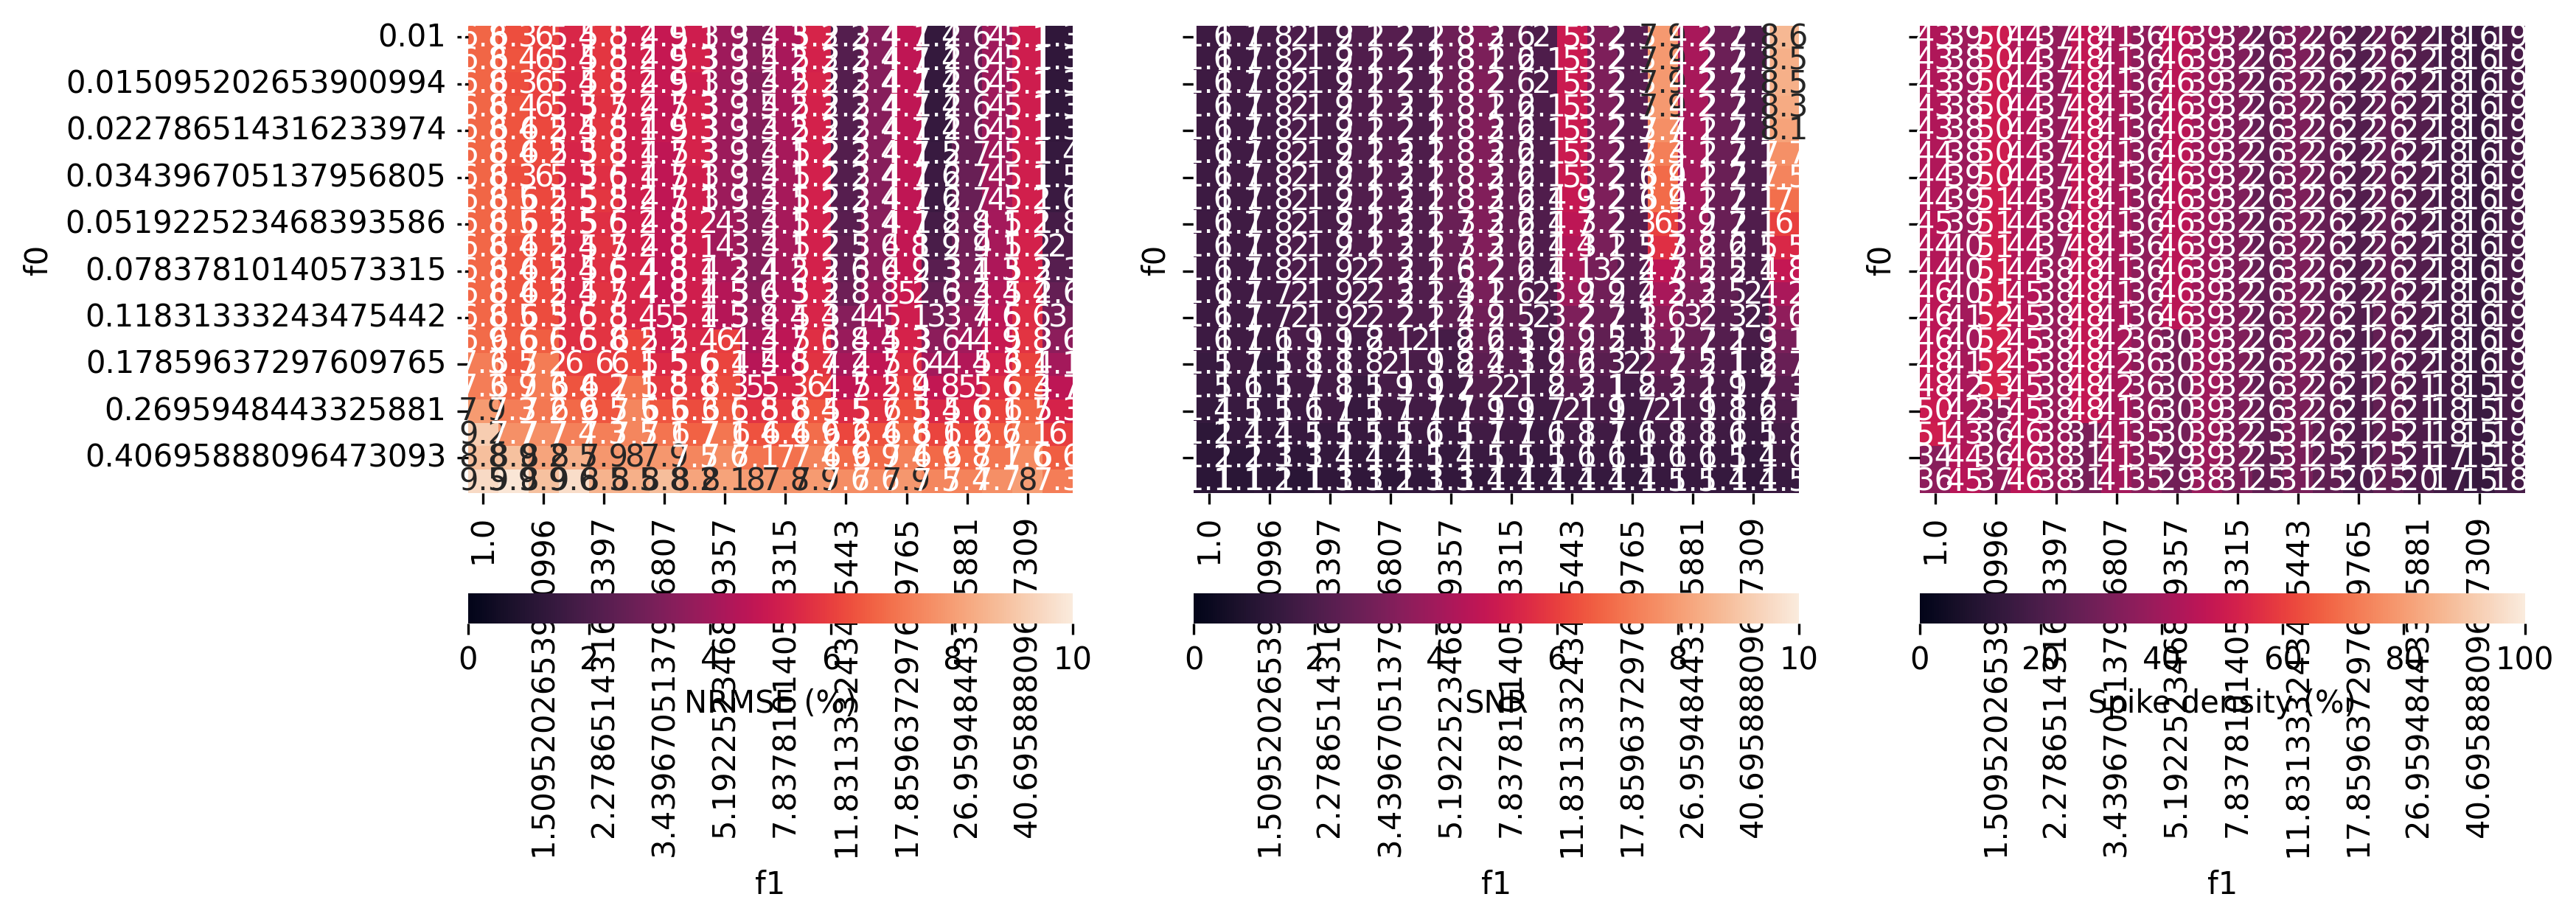

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12,4), sharex=True, sharey=True)

sn.heatmap(df.pivot(index='f0', columns='f1', values='nrmse') * 100, vmin=0, vmax=10, annot=False, ax=ax[0], annot_kws={'size':'x-small'}, cbar_kws={'location':'bottom', 'label':'NRMSE (%)'})
sn.heatmap(df.pivot(index='f0', columns='f1', values='snr'), vmin=0, vmax=10, annot=False, ax=ax[1], annot_kws={'size':'x-small'}, cbar_kws={'location':'bottom', 'label':'SNR'})
sn.heatmap(df.pivot(index='f0', columns='f1', values='spks') * 100, vmin=0, vmax=100, annot=False, ax=ax[2], annot_kws={'size':'x-small'}, cbar_kws={'location':'bottom', 'label':'Spike density (%)'})

fig, ax = plt.subplots(1, 1, figsize=(6,4), sharex=True, sharey=True)

sn.heatmap(df.pivot(index='f0', columns='f1', values='snr per spks'), vmin=0, vmax=20, annot=True, ax=ax, annot_kws={'size':'small'}, cbar_kws={'location':'bottom', 'label':'SNR / Spike Density'})

In [ ]:
df.to_csv('./xyloIMU_metrics_linearfreq.csv')

In [ ]:
df = pd.read_csv('/Users/igavier/Documents/GitHub/Neuromorphic-IMU/notebooks/waveletFIR_metrics_logarithmicfreq.csv')
df.replace({"nan": np.nan, "inf": np.inf}, inplace=True)
df.f0 = np.round(df.f0, 3)
df.f1 = np.round(df.f1, 1)
df['snr per spks'] = 10 * np.log10(df['snr per spks'])
df['snr'] = 10 * np.log10(df['snr'])
df
# df = pd.DataFrame(columns=['f0', 'f1', 'nrmse', 'snr', 'spks', 'snr per spks'],
#                   data=[[float(c) for c in r.split(' ')] for r in data.split('\n')])

,f0,f1,nrmse,snr,spks,snr per spks
0,0.01,1.0,0.081952,0.616599,0.002446,26.732449
1,0.01,1.2,0.080936,0.823985,0.003016,26.029718
2,0.01,1.5,0.075914,1.118560,0.003514,25.659944
3,0.01,1.9,0.071588,1.445112,0.004077,25.341528
4,0.01,2.3,0.067224,1.843708,0.004633,25.185299
...,...,...,...,...,...,...
395,0.50,21.9,0.030093,5.597823,0.020377,22.506512
396,0.50,27.0,0.031920,5.341702,0.019736,22.389170
397,0.50,33.1,0.034038,5.062366,0.019014,22.271704
398,0.50,40.7,0.036192,4.795640,0.018394,22.148831


<Axes: xlabel='f1', ylabel='f0'>

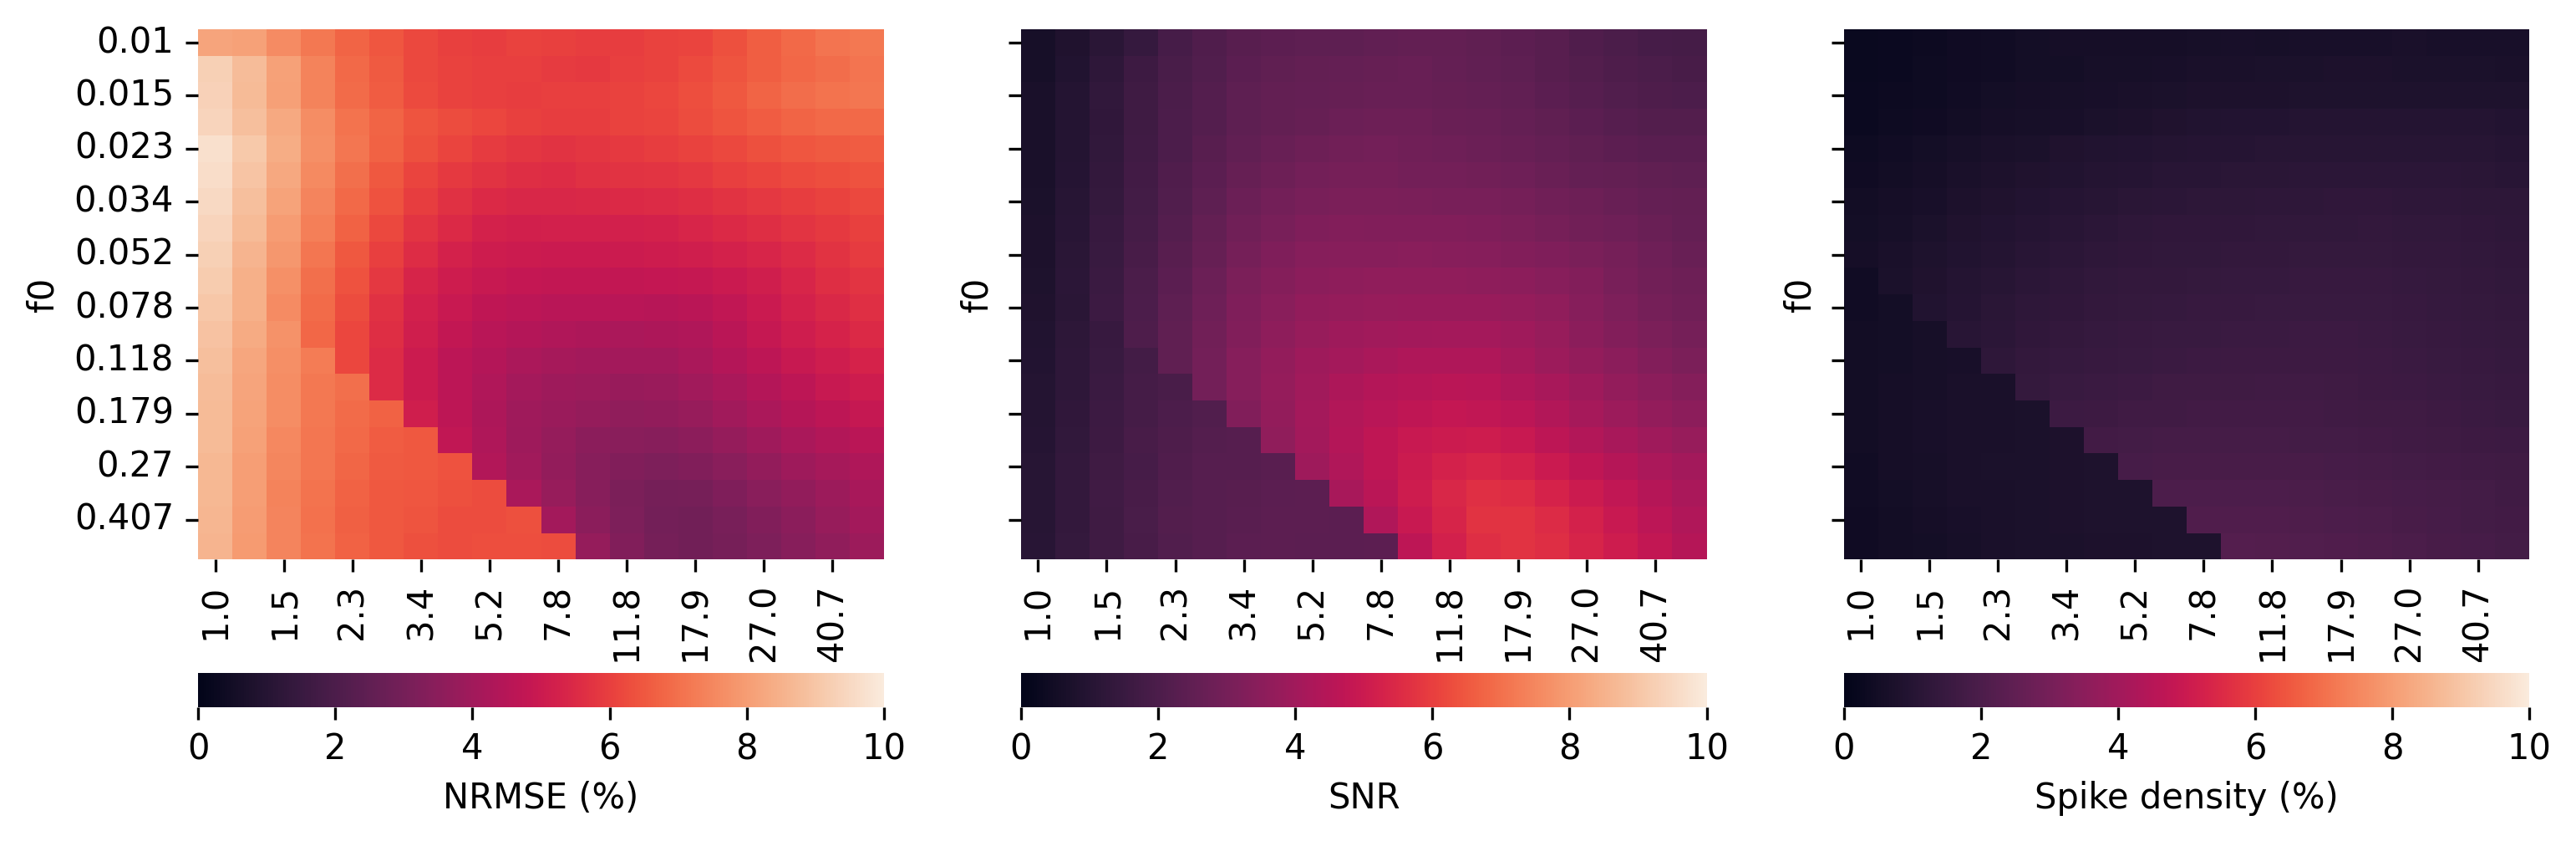

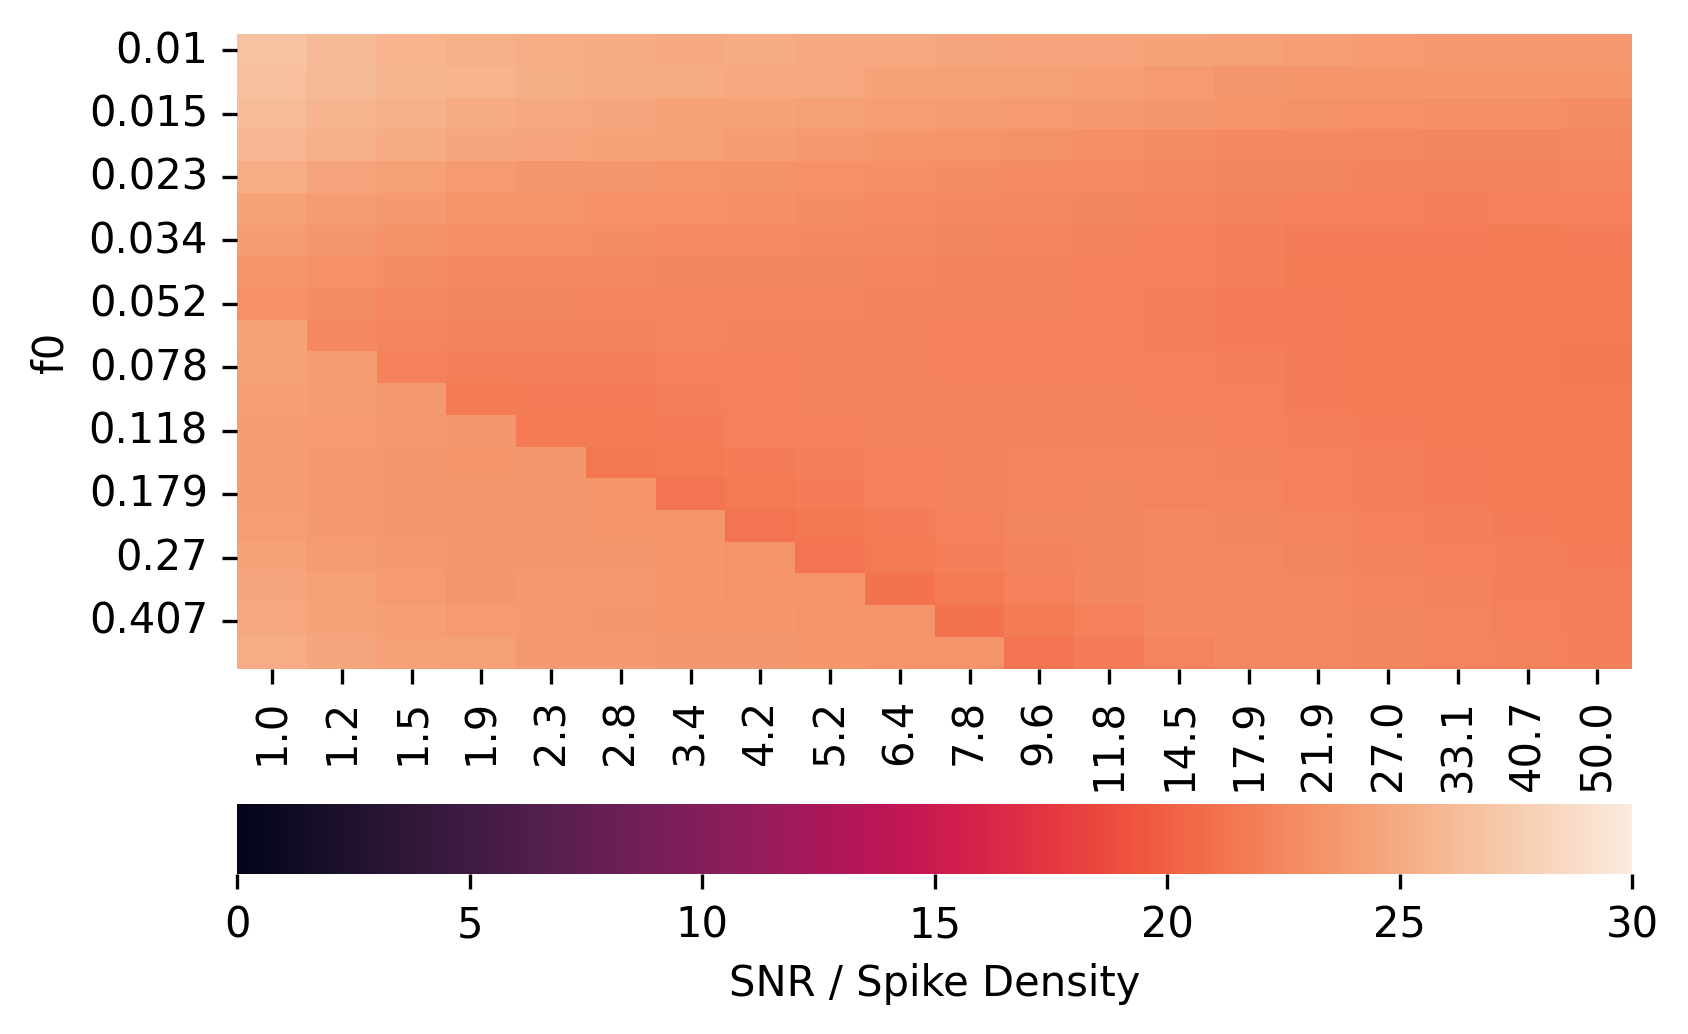

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12,4), sharex=True, sharey=True)

sn.heatmap(df.pivot(index='f0', columns='f1', values='nrmse') * 100, vmin=0, vmax=10, annot=False, ax=ax[0], annot_kws={'size':'x-small'}, cbar_kws={'location':'bottom', 'label':'NRMSE (%)'})
sn.heatmap(df.pivot(index='f0', columns='f1', values='snr'), vmin=0, vmax=10, annot=False, ax=ax[1], annot_kws={'size':'x-small'}, cbar_kws={'location':'bottom', 'label':'SNR'})
sn.heatmap(df.pivot(index='f0', columns='f1', values='spks') * 100, vmin=0, vmax=10, annot=False, ax=ax[2], annot_kws={'size':'x-small'}, cbar_kws={'location':'bottom', 'label':'Spike density (%)'})

fig, ax = plt.subplots(1, 1, figsize=(6,4), sharex=True, sharey=True)

sn.heatmap(df.pivot(index='f0', columns='f1', values='snr per spks'), vmin=0, vmax=30, annot=False, fmt='.0f', ax=ax, annot_kws={'size':'small'}, cbar_kws={'location':'bottom', 'label':'SNR / Spike Density'})

In [ ]:
df[(df['f0']<df['f1']*0.052)*(df['snr']>3.8)*(df['snr per spks']>22.5)]

,f0,f1,nrmse,snr,spks,snr per spks
313,0.219,14.5,0.034081,5.067284,0.017948,22.527159
333,0.270,14.5,0.031774,5.368702,0.018852,22.615041
334,0.270,17.9,0.032613,5.255585,0.018536,22.575431
353,0.331,14.5,0.029920,5.628743,0.019732,22.677064
354,0.331,17.9,0.030436,5.554116,0.019378,22.680922
355,0.331,21.9,0.032254,5.301761,0.018999,22.514393
373,0.407,14.5,0.029364,5.707225,0.020660,22.555999
374,0.407,17.9,0.029233,5.726321,0.020226,22.667236
375,0.407,21.9,0.030594,5.528427,0.019711,22.581285
394,0.500,17.9,0.029240,5.723043,0.020796,22.543229
